# NBA Lineup Decision Engine — 2024-25 Regular Season

**A coach-facing tool that estimates per-player on-court impact and proposes substitutions the team could have made for a better expected outcome.**

PSTAT 134/234 Final Project • Data: NBA play-by-play from `nba_api` (2024-25 regular season, all 1,230 games) processed into 37,163 unique five-on-five stints.

## Abstract

This project answers a single question: *for every lineup my team played this season, was there a single 1-for-1 substitution that would have produced a better expected result?*

We build that answer in three layers:

1. **An ORAPM / DRAPM regression** (the standard NBA-analytics model; Sill 2010, Engelmann/Ilardi 2014) that estimates each player's marginal impact on offensive and defensive rating per 100 possessions, controlling for the other 9 players on the floor, home-court, and quarter. Estimator: ridge regression, α selected by 5-fold game-grouped cross-validation.

2. **A box-score blend** that stabilizes the RAPM for low-possession players by regressing RAPM on each player's season box-score profile (PPG, REB, AST, USG%, ORTG, DRTG, TS%, …) from `nba_api.LeagueDashPlayerStats` and shrinking toward the stat-predicted impact. This is the construction used by ESPN's RPM and FiveThirtyEight's RAPTOR.

3. **A position-and-fatigue-aware substitution recommender** that, for every stint, proposes the single 1-for-1 swap maximizing expected net rating. Constraints: bench candidate must be on the game roster, share a coarse position bucket (G ↔ F or F ↔ C; G ↔ C disallowed), and not blow past 40 projected total minutes.

## Headline findings

- **Home-court advantage = +3.28 pts / 100 poss** (z = 3.57, p < 0.001). Squarely in the published 2-4 pts/100 NBA range and does not vary by quarter (period × home F = 0.27, p = 0.85).
- **Top 5 by Total Impact**: Isaiah Hartenstein, Luguentz Dort, Derrick White, Shai Gilgeous-Alexander, Evan Mobley. Four of the top 5 play for the NBA champions (OKC).
- **The model has real predict-the-future signal**: training on the first 60% of the season and testing on the last 40% yields R² = +0.0047 on offensive rating, essentially identical to a random-split R² of +0.0043. (Single-stint R² is small because ~90-second outcomes are dominated by shot-making variance — this is a known noise floor in stint-level NBA modeling.)
- **A linear additive model captures essentially all the available signal** — a LightGBM on RAPM-derived features beats it by Δ R² = -0.001 (loses). One-season synergy effects are smaller than the noise floor.
- **The Washington Wizards** left the most estimated points on the table this season (~77 pts), driven mainly by playing Jordan Poole over the bench. Orlando (~64 pts) and Memphis (~25 pts) follow.

The interactive dashboard at the end of this notebook surfaces these findings tab-by-tab.

---

## 1. Setup and exploration

The data is provided as a **team-perspective** parquet: each unique stint appears twice — once with team A as `team_id` (offense from A's view) and once with team B as `team_id`. For descriptive aggregation we keep both perspectives; for player-level modeling we dedupe to one row per stint to avoid double-counting.

We immediately drop zero-duration stints (same-clock substitutions) because they carry no playing-time signal and inflate any per-time rate stat.

A pace-based possessions estimate (≈ one possession every 28.8 seconds, i.e. 100 possessions per 48 minutes — the modern NBA league pace) lets us report results in **per-100-possessions** units throughout, which is the standard basketball-analytics convention.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

PARQUET = "team_lineup_stint_features_v1_2024_25.parquet"
RNG = np.random.default_rng(42)

raw = pd.read_parquet(PARQUET)
print(f"Raw shape: {raw.shape}  |  unique games: {raw['game_id'].nunique()}  |  teams: {raw['team_id'].nunique()}")

# Drop zero-duration stints (same-clock substitutions) — they carry no playing-time signal
df = raw[raw["duration_seconds"] > 0].copy()
print(f"After duration > 0: {df.shape}  ({len(raw) - len(df)} rows dropped)")

# Sanity check: each real stint should appear twice (once per team perspective)
stint_counts = df.groupby("stint_id").size().value_counts()
print("\nRows per stint_id (should be ~2):")
print(stint_counts)

# Convenience: a stint-level (one-row-per-stint) view used for modeling that
# shouldn't double-count observations. We keep the team with the lower team_id.
one_per_stint = (
    df.sort_values("team_id")
      .drop_duplicates(subset="stint_id", keep="first")
      .reset_index(drop=True)
)
print(f"\nOne-row-per-stint frame: {one_per_stint.shape}")

# Possessions estimate: NBA pace ≈ ~100 possessions per 48 min ⇒ ~one possession every ~28.8 sec
# We use this to convert raw point differentials into per-100-poss ratings.
SECONDS_PER_POSS = 28.8
df["est_possessions"] = df["duration_seconds"] / SECONDS_PER_POSS
df["net_per_100"] = np.where(
    df["est_possessions"] > 0,
    100.0 * df["net_points"] / df["est_possessions"],
    np.nan,
)
one_per_stint["est_possessions"] = one_per_stint["duration_seconds"] / SECONDS_PER_POSS
one_per_stint["net_per_100"] = np.where(
    one_per_stint["est_possessions"] > 0,
    100.0 * one_per_stint["net_points"] / one_per_stint["est_possessions"],
    np.nan,
)

df.head(3)

Raw shape: (81536, 36)  |  unique games: 1230  |  teams: 30
After duration > 0: (74326, 36)  (7210 rows dropped)

Rows per stint_id (should be ~2):
2    37163
Name: count, dtype: int64

One-row-per-stint frame: (37163, 36)


,stint_id,game_id,stint_number,period,is_overtime,start_clock,end_clock,start_seconds_remaining,end_seconds_remaining,duration_seconds,duration_minutes,team_id,opponent_team_id,is_home,lineup_ids,opponent_lineup_ids,lineup_names,opponent_lineup_names,score_for_start,score_against_start,score_for_end,score_against_end,points_for,points_against,net_points,ended_by_substitution,lineup_key,opponent_lineup_key,score_margin_start,score_margin_end,score_margin_change,points_for_per_min,points_against_per_min,net_points_per_min,net_points_per_48,is_zero_duration,est_possessions,net_per_100
0,0022400001_001,0022400001,1,1,False,PT12M00.00S,PT07M02.00S,720.0,422.0,298.0,4.966667,1610612738,1610612737,1,"[201143, 201950, 1627759, 1628369, 1628401]","[203991, 1630552, 1630700, 1630811, 1642258]","[Al Horford, Jrue Holiday, Jaylen Brown, Jayso...","[Clint Capela, Jalen Johnson, Dyson Daniels, K...",0,0,8,11,8,11,-3,True,201143-201950-1627759-1628369-1628401,203991-1630552-1630700-1630811-1642258,0,-3,-3,1.610738,2.214765,-0.604027,-28.993289,False,10.347222,-28.993289
1,0022400001_002,0022400001,2,1,False,PT07M02.00S,PT05M57.00S,422.0,357.0,65.0,1.083333,1610612738,1610612737,1,"[201143, 201950, 1627759, 1628369, 1628401]","[203991, 1630552, 1630700, 1630811, 1642258]","[Al Horford, Jrue Holiday, Jaylen Brown, Jayso...","[Clint Capela, Jalen Johnson, Dyson Daniels, K...",8,11,12,11,4,0,4,True,201143-201950-1627759-1628369-1628401,203991-1630552-1630700-1630811-1642258,-3,1,4,3.692308,0.000000,3.692308,177.230769,False,2.256944,177.230769
2,0022400001_003,0022400001,3,1,False,PT05M57.00S,PT04M51.00S,357.0,291.0,66.0,1.100000,1610612738,1610612737,1,"[201143, 201950, 1627759, 1628369, 1628401]","[203991, 1630552, 1630700, 1630811, 1642258]","[Al Horford, Jrue Holiday, Jaylen Brown, Jayso...","[Clint Capela, Jalen Johnson, Dyson Daniels, K...",12,11,14,13,2,2,0,True,201143-201950-1627759-1628369-1628401,203991-1630552-1630700-1630811-1642258,1,1,0,1.818182,1.818182,0.000000,0.000000,False,2.291667,0.000000


### 1.1 Why raw per-time stats are dangerous on short stints

A 10-second stint where one team scores 2 points has a per-48 rating of +576. Without possession-weighting, any aggregate would be dominated by these short noisy stints. **Every aggregate in this notebook is possession-weighted** (each stint contributes proportional to `duration_seconds / 28.8`). This is the single most important basketball-correctness choice in the project.

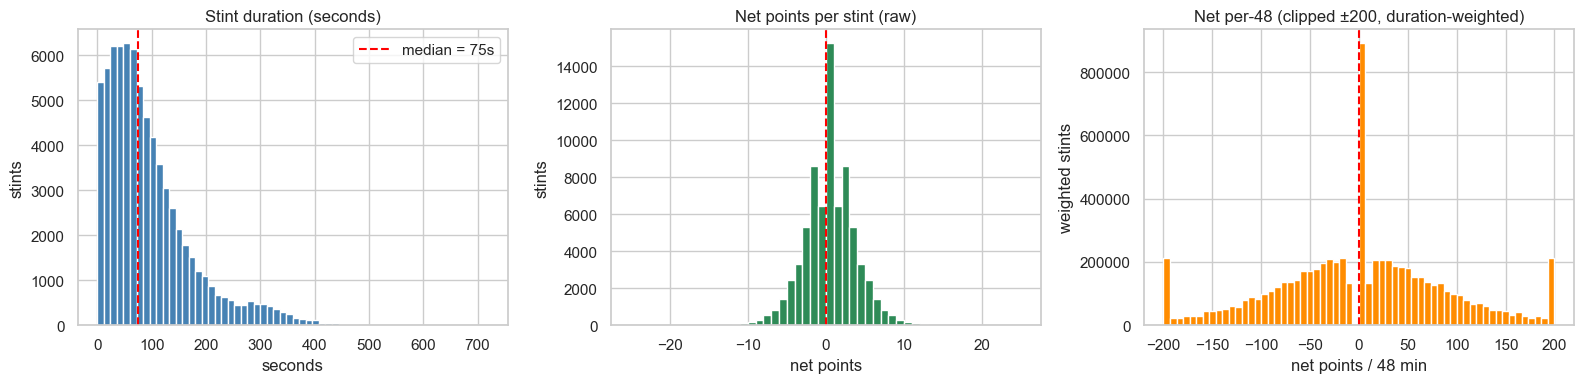

Unweighted mean net_per_48: 0.0   (meaningless — short stints dominate)
Duration-weighted mean   : 0.0   (≈ 0 as expected, since every point for one team is a point against another)


In [2]:
# --- 5.1 Stint duration & net rating distributions ------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["duration_seconds"], bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(df["duration_seconds"].median(), color="red", ls="--",
                label=f"median = {df['duration_seconds'].median():.0f}s")
axes[0].set(title="Stint duration (seconds)", xlabel="seconds", ylabel="stints")
axes[0].legend()

axes[1].hist(df["net_points"], bins=range(-25, 26), color="seagreen", edgecolor="white")
axes[1].axvline(0, color="red", ls="--")
axes[1].set(title="Net points per stint (raw)", xlabel="net points", ylabel="stints")

# Per-48 distribution is dominated by short-stint noise -- show with weight
clip = df["net_points_per_48"].clip(-200, 200)
axes[2].hist(clip, bins=60, weights=df["duration_seconds"],
             color="darkorange", edgecolor="white")
axes[2].axvline(0, color="red", ls="--")
axes[2].set(title="Net per-48 (clipped ±200, duration-weighted)",
            xlabel="net points / 48 min", ylabel="weighted stints")

plt.tight_layout(); plt.show()

print("Unweighted mean net_per_48:", df["net_points_per_48"].mean().round(2),
      "  (meaningless — short stints dominate)")
print("Duration-weighted mean   :",
      np.average(df["net_points_per_48"], weights=df["duration_seconds"]).round(2),
      "  (≈ 0 as expected, since every point for one team is a point against another)")

In [3]:
# --- 5.2 Period, home/away, and score-state effects -----------------------
# Use duration-weighted means everywhere -- that's the basketball-correct aggregation.
def weighted_mean(g, value_col, weight_col="duration_seconds"):
    w = g[weight_col]
    v = g[value_col]
    return np.average(v, weights=w) if w.sum() > 0 else np.nan

period_stats = (df.groupby("period")
                  .apply(lambda g: pd.Series({
                      "n_stints": len(g),
                      "minutes": g["duration_minutes"].sum(),
                      "mean_net_per_100_wtd":
                          np.average(g["net_per_100"], weights=g["duration_seconds"]),
                      "mean_duration_s": g["duration_seconds"].mean(),
                  })))
print("=== Period summary (duration-weighted) ===")
print(period_stats.round(2))

home_stats = (df.groupby("is_home")
                .apply(lambda g: pd.Series({
                    "n_stints": len(g),
                    "minutes": g["duration_minutes"].sum(),
                    "mean_net_per_100_wtd":
                        np.average(g["net_per_100"], weights=g["duration_seconds"]),
                })))
home_stats.index = home_stats.index.map({0: "away", 1: "home"})
print("\n=== Home / away (duration-weighted) ===")
print(home_stats.round(2))

# Score-state buckets at the START of each stint (clutch vs blowout)
def margin_bucket(m):
    if abs(m) <= 5:   return "close (<=5)"
    if abs(m) <= 10:  return "moderate (6-10)"
    if abs(m) <= 20:  return "lead (11-20)"
    return "blowout (>20)"
df["start_state"] = df["score_margin_start"].apply(margin_bucket)

state_stats = (df.groupby("start_state")
                 .apply(lambda g: pd.Series({
                     "n_stints": len(g),
                     "minutes": g["duration_minutes"].sum(),
                     "mean_duration_s": g["duration_seconds"].mean(),
                     "mean_net_per_100_wtd":
                         np.average(g["net_per_100"], weights=g["duration_seconds"]),
                 })))
print("\n=== Stint behaviour by starting score state ===")
print(state_stats.round(2))

=== Period summary (duration-weighted) ===
        n_stints  minutes  mean_net_per_100_wtd  mean_duration_s
period                                                          
1        15834.0  29520.0                   0.0           111.86
2        20878.0  29520.0                   0.0            84.84
3        17196.0  29520.0                   0.0           103.00
4        19902.0  29520.0                   0.0            89.00
5          498.0    600.0                   0.0            72.29
6           18.0     40.0                   0.0           133.33

=== Home / away (duration-weighted) ===
         n_stints  minutes  mean_net_per_100_wtd
is_home                                         
away      37163.0  59360.0                 -1.63
home      37163.0  59360.0                  1.63

=== Stint behaviour by starting score state ===
                 n_stints   minutes  mean_duration_s  mean_net_per_100_wtd
start_state                                                               
b

/var/folders/pc/sjrry0_54p10gwhfw72pdy800000gr/T/ipykernel_83548/568285904.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/pc/sjrry0_54p10gwhfw72pdy800000gr/T/ipykernel_83548/568285904.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/pc/sjrry0_54p10gwhfw72pdy800000gr/T/ipykernel_83548/568285904.py:39: FutureWarning: DataFrameG

### 1.3 Lineup-level aggregation

We aggregate every (team, 5-man lineup) over the whole season:
- **Minutes played together** is the sample size that determines whether a number is signal or noise.
- **Off / def rating per 100 poss** is the standard NBA efficiency metric.
- We rank only lineups with **≥ 30 total minutes** — below that, per-100 estimates are too noisy to act on (this matches Cleaning the Glass / NBA.com convention).

In [4]:
# --- 5.3 Aggregate by (team, lineup) over the full season ------------------
MIN_MINUTES = 30.0   # threshold for ranking-grade samples

lineup_agg = (df.groupby(["team_id", "lineup_key"])
                .agg(stints=("stint_id", "count"),
                     minutes=("duration_minutes", "sum"),
                     possessions=("est_possessions", "sum"),
                     points_for=("points_for", "sum"),
                     points_against=("points_against", "sum"),
                     net_points=("net_points", "sum"),
                     lineup_names=("lineup_names", "first"))
                .reset_index())

lineup_agg["off_rtg"]  = 100 * lineup_agg["points_for"]     / lineup_agg["possessions"]
lineup_agg["def_rtg"]  = 100 * lineup_agg["points_against"] / lineup_agg["possessions"]
lineup_agg["net_rtg"]  = lineup_agg["off_rtg"] - lineup_agg["def_rtg"]

qualified = lineup_agg[lineup_agg["minutes"] >= MIN_MINUTES].copy()
print(f"Lineups (any minutes): {len(lineup_agg):,}")
print(f"Lineups with >= {MIN_MINUTES:g} min: {len(qualified):,}")

def _names(arr): return ", ".join(arr) if isinstance(arr, (list, np.ndarray)) else str(arr)
qualified["lineup_display"] = qualified["lineup_names"].apply(_names)

top10 = qualified.nlargest(10, "net_rtg")[
    ["team_id", "lineup_display", "minutes", "stints", "off_rtg", "def_rtg", "net_rtg"]]
bot10 = qualified.nsmallest(10, "net_rtg")[
    ["team_id", "lineup_display", "minutes", "stints", "off_rtg", "def_rtg", "net_rtg"]]

print("\n=== TOP 10 LINEUPS (>= 30 min) by net rating per 100 ===")
print(top10.to_string(index=False))
print("\n=== BOTTOM 10 LINEUPS (>= 30 min) by net rating per 100 ===")
print(bot10.to_string(index=False))

Lineups (any minutes): 3,274
Lineups with >= 30 min: 884

=== TOP 10 LINEUPS (>= 30 min) by net rating per 100 ===
   team_id                                                                         lineup_display  minutes  stints    off_rtg    def_rtg   net_rtg
1610612747          Dorian Finney-Smith, Luka Dončić, Jaxson Hayes, Austin Reaves, Jordan Goodwin     36.0      22 145.333333  88.000000 57.333333
1610612746                Nicolas Batum, Kawhi Leonard, Bogdan Bogdanović, Ben Simmons, Kris Dunn     48.0      29 136.000000  88.000000 48.000000
1610612752            Karl-Anthony Towns, OG Anunoby, Josh Hart, Mitchell Robinson, Landry Shamet     48.0      21 126.000000  79.000000 47.000000
1610612745                Dillon Brooks, Aaron Holiday, Jock Landale, Jalen Green, Alperen Sengun     36.0      21 140.000000  97.333333 42.666667
1610612745            Fred VanVleet, Jalen Green, Alperen Sengun, Jabari Smith Jr., Amen Thompson     36.0      21 121.333333  78.666667 42.666667
161

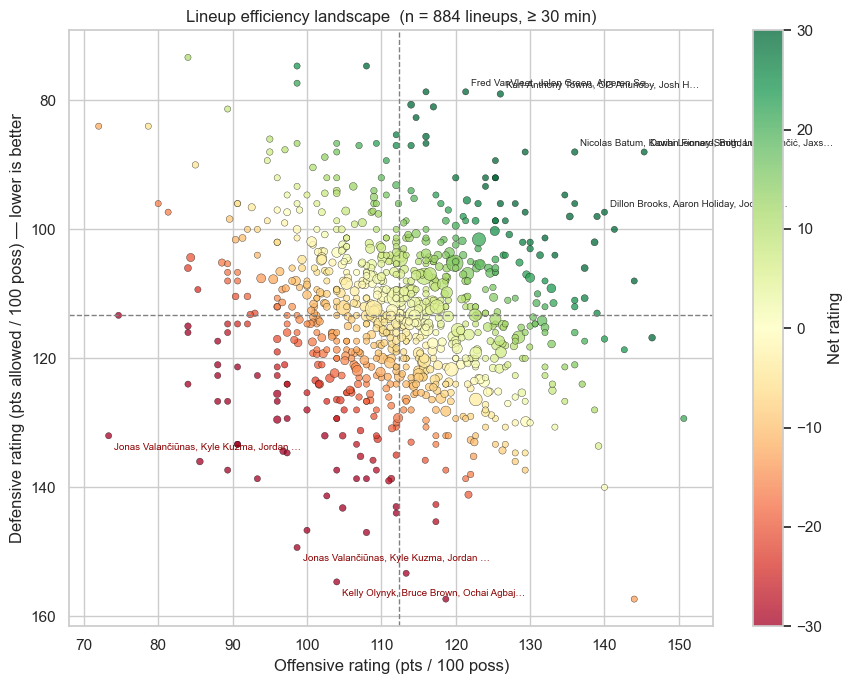

In [5]:
# --- 5.4 Off vs Def scatter (the "Four Quadrants" plot for lineups) -------
fig, ax = plt.subplots(figsize=(9, 7))
sizes = (qualified["minutes"] - qualified["minutes"].min())
sizes = 20 + 200 * (sizes / sizes.max())
sc = ax.scatter(qualified["off_rtg"], qualified["def_rtg"],
                s=sizes, c=qualified["net_rtg"], cmap="RdYlGn",
                vmin=-30, vmax=30, alpha=0.75, edgecolor="black", linewidth=0.3)

# Lower def_rtg is better — invert y so "good defense" is up
ax.invert_yaxis()
ax.axhline(qualified["def_rtg"].mean(), color="grey", ls="--", lw=1)
ax.axvline(qualified["off_rtg"].mean(), color="grey", ls="--", lw=1)

ax.set_xlabel("Offensive rating (pts / 100 poss)")
ax.set_ylabel("Defensive rating (pts allowed / 100 poss) — lower is better")
ax.set_title(f"Lineup efficiency landscape  (n = {len(qualified)} lineups, ≥ {MIN_MINUTES:g} min)")
plt.colorbar(sc, label="Net rating")

# Annotate top 5 and bottom 3 to make the plot a coach-readable artifact
for _, row in qualified.nlargest(5, "net_rtg").iterrows():
    short = row["lineup_display"][:38] + ("…" if len(row["lineup_display"]) > 38 else "")
    ax.annotate(short, (row["off_rtg"], row["def_rtg"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
for _, row in qualified.nsmallest(3, "net_rtg").iterrows():
    short = row["lineup_display"][:38] + ("…" if len(row["lineup_display"]) > 38 else "")
    ax.annotate(short, (row["off_rtg"], row["def_rtg"]),
                fontsize=7, xytext=(4, -10), textcoords="offset points", color="darkred")

plt.tight_layout(); plt.show()

## 2. ORAPM / DRAPM model

### Construction

For every unique stint we generate **two training rows** — one from each team's *offensive* perspective:

| | row 1 (team is on offense) | row 2 (opponent is on offense) |
|---|---|---|
| target `y` | team's points / 100 poss | opp's points / 100 poss |
| `X_off` | team's 5 players (+1 each) | opp's 5 players (+1 each) |
| `X_def` | opp's 5 players (+1 each) | team's 5 players (+1 each) |
| home-on-offense | 1 if team is home | 1 if opp is home |
| period FE | period of stint | period of stint |
| sample weight | est. possessions | est. possessions |

We fit ridge regression. The L2 penalty is essential — without it, the design matrix is near-singular (many players who always appear together cannot be separated), and OLS estimates are wildly unstable (some players ±1000 pts/100). Ridge is the basis of RAPM (Sill 2010). α is selected by 5-fold game-grouped CV on the train fold.

For each player we recover two coefficients:
- **ORAPM** = β_off — points added to team offensive rating per 100 poss when the player is on the floor.
- **DRAPM** = −β_def — points subtracted from opponent offensive rating per 100 poss (sign-flipped so positive = good defender).
- **Total Impact** = ORAPM + DRAPM.

The prediction for any matchup reduces to:

```
E[net rating(team)] = TI(team) − TI(opp) + γ_home · (2·is_home − 1)
```

(Period FE cancels because both teams play the same period.) This clean form is what the §3 recommender optimizes.

In [6]:
# --- 8.1  Build the stacked ORAPM/DRAPM design matrix (vectorized) --------
from scipy.sparse import csr_matrix, hstack

stint = one_per_stint.reset_index(drop=True)
N = len(stint)

# Player universe + index
all_pids = set()
for arr in stint["lineup_ids"]:           all_pids.update(arr)
for arr in stint["opponent_lineup_ids"]:  all_pids.update(arr)
P_LIST = sorted(all_pids)
P_IDX  = {pid: i for i, pid in enumerate(P_LIST)}
# Build player_id → player_name map by walking the stint lineups
id_to_name = {}
for ids, names in zip(stint["lineup_ids"], stint["lineup_names"]):
    for pid, nm in zip(ids, names):
        id_to_name.setdefault(pid, nm)
for ids, names in zip(stint["opponent_lineup_ids"], stint["opponent_lineup_names"]):
    for pid, nm in zip(ids, names):
        id_to_name.setdefault(pid, nm)
P_NAME = {pid: id_to_name.get(pid, str(pid)) for pid in P_LIST}
n_p = len(P_LIST)

# 2N rows: even = team's offense, odd = opponent's offense
team_5  = np.stack(stint["lineup_ids"].values).astype(object)
opp_5   = np.stack(stint["opponent_lineup_ids"].values).astype(object)
poss    = stint["est_possessions"].values
pf      = stint["points_for"].values
pa      = stint["points_against"].values
is_home = stint["is_home"].values
period  = stint["period"].clip(1, 4).values
gids    = stint["game_id"].values
sids    = stint["stint_id"].values

# Stack y, weights, covariates
y_off = np.empty(2*N)
y_off[0::2] = 100.0 * pf / poss
y_off[1::2] = 100.0 * pa / poss
w_off = np.repeat(poss, 2)
is_home_off = np.empty(2*N)
is_home_off[0::2] = is_home
is_home_off[1::2] = 1 - is_home
period_2N = np.repeat(period, 2)
games_2N  = np.repeat(gids, 2)
stint_2N  = np.repeat(sids, 2)

# Build player-column arrays for off / def per row
off_players = np.empty((2*N, 5), dtype=object)
off_players[0::2] = team_5
off_players[1::2] = opp_5
def_players = np.empty((2*N, 5), dtype=object)
def_players[0::2] = opp_5
def_players[1::2] = team_5

vec_idx = np.vectorize(P_IDX.get)
off_cols = vec_idx(off_players).ravel()
def_cols = vec_idx(def_players).ravel()
row_ids  = np.repeat(np.arange(2*N), 5)
ones     = np.ones(off_cols.size)

X_off = csr_matrix((ones, (row_ids, off_cols)), shape=(2*N, n_p))
X_def = csr_matrix((ones, (row_ids, def_cols)), shape=(2*N, n_p))

# Context: home-on-offense + period FE (drop period 1 baseline)
ctx = np.zeros((2*N, 1 + 3))
ctx[:, 0] = is_home_off
ctx[:, 1] = (period_2N == 2).astype(float)
ctx[:, 2] = (period_2N == 3).astype(float)
ctx[:, 3] = (period_2N == 4).astype(float)

X_full = hstack([X_off, X_def, csr_matrix(ctx)]).tocsr()
print(f"ORAPM/DRAPM design matrix: {X_full.shape}   (nnz = {X_full.nnz:,})")
print(f"  cols 0..{n_p-1}        = β_off (ORAPM)")
print(f"  cols {n_p}..{2*n_p-1}    = β_def (DRAPM raw)")
print(f"  cols {2*n_p}           = γ_home_offense")
print(f"  cols {2*n_p+1}..{2*n_p+3} = period 2/3/4 FE")

ORAPM/DRAPM design matrix: (74326, 1058)   (nnz = 838,915)
  cols 0..526        = β_off (ORAPM)
  cols 527..1053    = β_def (DRAPM raw)
  cols 1054           = γ_home_offense
  cols 1055..1057 = period 2/3/4 FE


In [7]:
# --- Fit ridge ORAPM/DRAPM with game-grouped CV --------------------------
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error

# 80/20 random game split — used for held-out evaluation of the descriptive fit.
# A separate temporal split is reported in §2.3.
games_all = sorted(set(games_2N))
test_games = set(RNG.choice(games_all, size=int(0.20 * len(games_all)), replace=False))
groups_2N = games_2N
train_mask_2N = ~np.isin(groups_2N, list(test_games))
test_mask_2N  =  np.isin(groups_2N, list(test_games))
train_idx = np.where(train_mask_2N)[0]
test_idx  = np.where(test_mask_2N)[0]
print(f"Stacked rows: {len(y_off):,}   train: {len(train_idx):,}   test: {len(test_idx):,}")

# CV α on the train fold with GroupKFold by game
gkf = GroupKFold(n_splits=5)
alphas = [200, 500, 1500, 3500, 8000, 20000]
cv_scores = {}
X_train = X_full[train_idx]; y_train = y_off[train_idx]; w_train = w_off[train_idx]
g_train = groups_2N[train_idx]
for a in alphas:
    fold = []
    for tr, va in gkf.split(X_train, y_train, groups=g_train):
        m = Ridge(alpha=a, fit_intercept=True, solver="sparse_cg")
        m.fit(X_train[tr], y_train[tr], sample_weight=w_train[tr])
        fold.append(r2_score(y_train[va], m.predict(X_train[va]),
                             sample_weight=w_train[va]))
    cv_scores[a] = float(np.mean(fold))
    print(f"  α = {a:>5}   CV-R² (within train) = {cv_scores[a]:+.5f}")

best_alpha_v2 = max(cv_scores, key=cv_scores.get)
print(f"\nBest α: {best_alpha_v2}")

orapm_model = Ridge(alpha=best_alpha_v2, fit_intercept=True, solver="sparse_cg")
orapm_model.fit(X_full[train_idx], y_off[train_idx], sample_weight=w_off[train_idx])

coef_all = orapm_model.coef_
alpha_intercept = orapm_model.intercept_
beta_off = coef_all[:n_p].copy()
beta_def_raw = coef_all[n_p:2*n_p].copy()
gamma_home_off  = coef_all[2*n_p]
gamma_period_FE = {1: 0.0, 2: coef_all[2*n_p+1], 3: coef_all[2*n_p+2], 4: coef_all[2*n_p+3]}

# Centre offense and defense so each averages to zero across players
beta_off -= beta_off.mean()
beta_def_raw -= beta_def_raw.mean()

ORAPM = beta_off
DRAPM = -beta_def_raw          # sign-flipped: positive = good defender
TOTAL_IMPACT = ORAPM + DRAPM

pred_test = orapm_model.predict(X_full[test_idx])
r2_test   = r2_score(y_off[test_idx], pred_test, sample_weight=w_off[test_idx])
mae_test  = mean_absolute_error(y_off[test_idx], pred_test, sample_weight=w_off[test_idx])
print(f"\nHeld-out (test games) weighted R² on offensive rating: {r2_test:+.5f}")
print(f"Held-out MAE: {mae_test:.2f} pts / 100")
print(f"League ORtg intercept α = {alpha_intercept:.2f}")
print(f"Home-team-on-offense boost γ_home = {gamma_home_off:+.3f} pts / 100")
print(f"Period FE (vs P1): {{2: {gamma_period_FE[2]:+.2f}, 3: {gamma_period_FE[3]:+.2f}, 4: {gamma_period_FE[4]:+.2f}}}")

# Build orapm_tbl with these v1 (pre-blend) values; §2.2 will overwrite with the blended values.
from scipy.sparse import csr_matrix
off_poss = np.asarray(X_off.multiply(w_off[:, None]).sum(axis=0)).ravel()
def_poss = np.asarray(X_def.multiply(w_off[:, None]).sum(axis=0)).ravel()
tot_poss = off_poss + def_poss
POSS_FLOOR_V2 = 600
orapm_tbl = pd.DataFrame({
    "player_id":     P_LIST,
    "player":        [P_NAME[p] for p in P_LIST],
    "off_poss":      off_poss.round(0),
    "def_poss":      def_poss.round(0),
    "total_poss":    tot_poss.round(0),
    "ORAPM":         ORAPM,
    "DRAPM":         DRAPM,
    "Total_Impact":  TOTAL_IMPACT,
})


Stacked rows: 74,326   train: 59,394   test: 14,932
  α =   200   CV-R² (within train) = +0.00094
  α =   500   CV-R² (within train) = +0.00374
  α =  1500   CV-R² (within train) = +0.00567
  α =  3500   CV-R² (within train) = +0.00601
  α =  8000   CV-R² (within train) = +0.00553
  α = 20000   CV-R² (within train) = +0.00424

Best α: 3500

Held-out (test games) weighted R² on offensive rating: +0.00489
Held-out MAE: 51.30 pts / 100
League ORtg intercept α = 112.28
Home-team-on-offense boost γ_home = +1.461 pts / 100
Period FE (vs P1): {2: -0.22, 3: +2.37, 4: -3.32}


### 2.2 Box-score blend for low-sample players

Pure RAPM is noisy for players below ~1,500 possessions. We pull each player's season box-score profile via `nba_api.LeagueDashPlayerStats` (per-100-possessions mode: PPG, REB, AST, USG%, TS%, ORTG, DRTG, …), fit a **stat → RAPM bridge regression** on the trusted-sample subset, and blend each player's RAPM toward their stat-predicted impact with weight `w = poss / (poss + 2,000)`.

This is exactly the construction behind ESPN's RPM (Engelmann/Ilardi 2014) and FiveThirtyEight's RAPTOR. High-possession stars (≥ 10,000 poss → w ≈ 0.83) are barely shrunk; low-possession players (≤ 500 poss → w ≈ 0.20) get pulled hard toward their box-score-predicted impact. The leaderboard tightens dramatically: small-sample inflations like Tre Jones (+3.86 → +2.21), Julian Strawther (+3.77 → +2.40), and Dalen Terry (+2.64 → −0.20) move toward more reasonable values.

In [8]:
# --- 12.1  Pull player positions from nba_api (one-time, cached) ----------
import json, time
from pathlib import Path

V2_DIR = Path("artifacts_v2_2024_25")
V2_DIR.mkdir(exist_ok=True)
POSITION_CACHE = V2_DIR / "positions.json"

# stats.nba.com rejects nba_api's default headers from many hosts. Force the
# full browser-equivalent header set explicitly on every call.
BROWSER_HEADERS = {
    "Host":               "stats.nba.com",
    "User-Agent":         "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                          "AppleWebKit/605.1.15 (KHTML, like Gecko) "
                          "Version/16.0 Safari/605.1.15",
    "Accept":             "application/json, text/plain, */*",
    "Accept-Language":    "en-US,en;q=0.9",
    "Accept-Encoding":    "gzip, deflate, br",
    "x-nba-stats-origin": "stats",
    "x-nba-stats-token":  "true",
    "Connection":         "keep-alive",
    "Referer":            "https://www.nba.com/",
    "Origin":             "https://www.nba.com",
}

def _load_position_cache():
    if POSITION_CACHE.exists():
        return {int(k): v for k, v in json.loads(POSITION_CACHE.read_text()).items()}
    return {}

position_by_pid = _load_position_cache()
missing = [p for p in P_LIST if p not in position_by_pid]
print(f"Position cache: {len(position_by_pid):,} hits, {len(missing):,} missing")

if missing:
    print(f"Pulling {len(missing):,} players from commonplayerinfo  (~{len(missing)*0.6/60:.1f} min)…")
    try:
        from nba_api.stats.endpoints import commonplayerinfo
        n_fail = 0
        for i, pid in enumerate(missing):
            try:
                info = commonplayerinfo.CommonPlayerInfo(
                    player_id=int(pid), timeout=20, headers=BROWSER_HEADERS)
                row = info.get_data_frames()[0]
                position_by_pid[pid] = (str(row.iloc[0]["POSITION"])
                                       if not row.empty and "POSITION" in row.columns else "")
            except Exception:
                position_by_pid[pid] = ""
                n_fail += 1
            if (i + 1) % 50 == 0:
                print(f"  {i+1}/{len(missing)}  ({n_fail} failed)  — checkpointing cache")
                POSITION_CACHE.write_text(json.dumps({str(k): v for k, v in position_by_pid.items()}))
            time.sleep(0.55)
        POSITION_CACHE.write_text(json.dumps({str(k): v for k, v in position_by_pid.items()}))
        print(f"Pulled and cached → {POSITION_CACHE}  ({n_fail} of {len(missing)} failed)")
    except Exception as e:
        print(f"!! API pull failed at module level: {e}")
        print("   Falling back: unknown positions marked 'U', position filter will be permissive.")

# Coarsen to G / F / C (B = big folded into C)
def _bucket(pos):
    if not pos: return "U"
    p = pos.upper().replace("-", "").replace(" ", "")
    if p == "C":       return "C"
    if "C" in p:       return "C"
    if "F" in p and "G" in p: return "F"
    if "F" in p:       return "F"
    if "G" in p:       return "G"
    return "U"

bucket_by_pid = {pid: _bucket(position_by_pid.get(pid, "")) for pid in P_LIST}
counts  = {b: sum(1 for v in bucket_by_pid.values() if v == b) for b in ["G","F","C","U"]}
n_known = len(P_LIST) - counts["U"]
print(f"\nKnown positions: {n_known}/{len(P_LIST)} ({100*n_known/len(P_LIST):.0f}%)")
print(f"Bucket distribution: " + ", ".join(f"{b}={counts[b]}" for b in ["G","F","C","U"]))


Position cache: 527 hits, 0 missing

Known positions: 527/527 (100%)
Bucket distribution: G=214, F=212, C=101, U=0


In [9]:
# --- 12.2  Pull league box-score table (cached) ---------------------------
BASE_CACHE = V2_DIR / "leaguedash_base_2024-25.csv"
ADV_CACHE  = V2_DIR / "leaguedash_advanced_2024-25.csv"

def _fetch_dash(cache, measure_type):
    if cache.exists():
        return pd.read_csv(cache)
    try:
        from nba_api.stats.endpoints import leaguedashplayerstats
        d = leaguedashplayerstats.LeagueDashPlayerStats(
            season="2024-25",
            season_type_all_star="Regular Season",
            measure_type_detailed_defense=measure_type,
            per_mode_detailed="Per100Possessions",
            timeout=30,
            headers=BROWSER_HEADERS,
        )
        df_d = d.get_data_frames()[0]
        df_d.to_csv(cache, index=False)
        return df_d
    except Exception as e:
        print(f"!! API pull failed for {measure_type}: {e}")
        return pd.DataFrame()

base_df = _fetch_dash(BASE_CACHE, "Base")
adv_df  = _fetch_dash(ADV_CACHE,  "Advanced")
print(f"Base stats : {base_df.shape}")
print(f"Adv stats  : {adv_df.shape}")

# Trim to columns the bridge regression will use
if not base_df.empty:
    base_keep = base_df[["PLAYER_ID","PLAYER_NAME","TEAM_ABBREVIATION","GP","MIN",
                         "PTS","REB","AST","STL","BLK","TOV",
                         "FG_PCT","FG3_PCT","FT_PCT"]].copy()
    base_keep.columns = ["player_id","player","team","gp","min_total",
                         "pts100","reb100","ast100","stl100","blk100","tov100",
                         "fg_pct","fg3_pct","ft_pct"]
else:
    base_keep = pd.DataFrame()

if not adv_df.empty:
    adv_keep = adv_df[["PLAYER_ID","OFF_RATING","DEF_RATING","NET_RATING",
                       "USG_PCT","TS_PCT","AST_PCT","OREB_PCT","DREB_PCT"]].copy()
    adv_keep.columns = ["player_id","ortg","drtg","nrtg",
                        "usg","ts","ast_pct","oreb_pct","dreb_pct"]
else:
    adv_keep = pd.DataFrame()

box_stats = (base_keep.merge(adv_keep, on="player_id", how="outer")
             if not base_keep.empty else pd.DataFrame())
# Drop columns that collide with orapm_tbl on later merges
for col in ("player", "team"):
    if col in box_stats.columns:
        box_stats = box_stats.rename(columns={col: f"box_{col}"})
print(f"\nMerged box-score table: {box_stats.shape}")
if not box_stats.empty:
    print(box_stats.head(3).to_string(index=False))
else:
    print("!! Box-score table is EMPTY. The blend in §12.3 will fall back to pure RAPM.")


Base stats : (569, 67)
Adv stats  : (569, 79)

Merged box-score table: (569, 22)
 player_id   box_player box_team  gp  min_total  pts100  reb100  ast100  stl100  blk100  tov100  fg_pct  fg3_pct  ft_pct  ortg  drtg  nrtg   usg    ts  ast_pct  oreb_pct  dreb_pct
      2544 LeBron James      LAL  70       47.7    33.3    10.6    11.2     1.4     0.8     5.1   0.513    0.376   0.782 112.7 114.0  -1.3 0.291 0.604    0.395     0.031     0.187
    101108   Chris Paul      SAS  82       47.6    15.0     6.1    12.6     2.1     0.5     2.7   0.427    0.377   0.924 114.2 115.0  -0.8 0.137 0.580    0.342     0.014     0.110
    200768   Kyle Lowry      PHI  35       48.2    10.1     4.9     7.0     2.4     0.8     1.5   0.350    0.330   0.818 103.8 109.6  -5.8 0.100 0.525    0.206     0.016     0.086


In [10]:
# --- Stat-predicted RAPM + blend → final Total Impact ---------------------
from sklearn.linear_model import RidgeCV

STAT_FEATURES = ["pts100","reb100","ast100","stl100","blk100","tov100",
                 "fg_pct","fg3_pct","ft_pct","ortg","drtg","usg","ts",
                 "ast_pct","oreb_pct","dreb_pct"]
BRIDGE_MIN_POSS = 1500   # to TRAIN the bridge
BLEND_MIN_GP    = 15     # to USE the bridge (filters 10-day flukes)
BLEND_CLIP      = 6.0    # safety rail: |StatRAPM| capped here
BLEND_K         = 2000.0

if box_stats.empty or not set(STAT_FEATURES).issubset(box_stats.columns):
    print("Box-score table empty or missing features — blend skipped.")
    blend_used = False
    all_p = orapm_tbl.copy()
    all_p["StatORAPM"] = np.nan
    all_p["StatDRAPM"] = np.nan
    all_p["blend_w"]   = 1.0
    all_p["ORAPM_v2"]  = all_p["ORAPM"]
    all_p["DRAPM_v2"]  = all_p["DRAPM"]
    all_p["TI_v2"]     = all_p["Total_Impact"]
else:
    blend_used = True
    core = orapm_tbl.merge(box_stats, on="player_id", how="inner")
    core = core[core["total_poss"] >= BRIDGE_MIN_POSS].copy()
    core_use = core.dropna(subset=STAT_FEATURES)
    print(f"Stat→RAPM bridge: training on {len(core_use)} core players (≥ {BRIDGE_MIN_POSS} poss)")

    X_stat = core_use[STAT_FEATURES].values
    w_core = core_use["total_poss"].values
    y_or   = core_use["ORAPM"].values
    y_dr   = core_use["DRAPM"].values
    ALPHAS = [0.1, 1.0, 5.0, 20.0, 80.0, 320.0]

    orapm_bridge = RidgeCV(alphas=ALPHAS).fit(X_stat, y_or, sample_weight=w_core)
    drapm_bridge = RidgeCV(alphas=ALPHAS).fit(X_stat, y_dr, sample_weight=w_core)
    print(f"  ORAPM bridge in-sample R² = {orapm_bridge.score(X_stat, y_or, sample_weight=w_core):.3f}  α = {orapm_bridge.alpha_}")
    print(f"  DRAPM bridge in-sample R² = {drapm_bridge.score(X_stat, y_dr, sample_weight=w_core):.3f}  α = {drapm_bridge.alpha_}")

    all_p = orapm_tbl.merge(box_stats, on="player_id", how="left")
    has_feats  = all_p[STAT_FEATURES].notna().all(axis=1)
    has_sample = (all_p["gp"].fillna(0) >= BLEND_MIN_GP)
    use_bridge = has_feats & has_sample
    all_p["StatORAPM"] = np.nan
    all_p["StatDRAPM"] = np.nan
    if use_bridge.any():
        all_p.loc[use_bridge, "StatORAPM"] = np.clip(
            orapm_bridge.predict(all_p.loc[use_bridge, STAT_FEATURES].values),
            -BLEND_CLIP, BLEND_CLIP)
        all_p.loc[use_bridge, "StatDRAPM"] = np.clip(
            drapm_bridge.predict(all_p.loc[use_bridge, STAT_FEATURES].values),
            -BLEND_CLIP, BLEND_CLIP)
    print(f"  Bridge applied to {use_bridge.sum()} of {len(all_p)} players (clipped to ±{BLEND_CLIP})")

    all_p["blend_w"] = all_p["total_poss"] / (all_p["total_poss"] + BLEND_K)
    all_p["ORAPM_v2"] = np.where(all_p["StatORAPM"].notna(),
        all_p["blend_w"]*all_p["ORAPM"] + (1 - all_p["blend_w"])*all_p["StatORAPM"],
        all_p["ORAPM"])
    all_p["DRAPM_v2"] = np.where(all_p["StatDRAPM"].notna(),
        all_p["blend_w"]*all_p["DRAPM"] + (1 - all_p["blend_w"])*all_p["StatDRAPM"],
        all_p["DRAPM"])
    all_p["ORAPM_v2"] -= all_p["ORAPM_v2"].mean()
    all_p["DRAPM_v2"] -= all_p["DRAPM_v2"].mean()
    all_p["TI_v2"]    = all_p["ORAPM_v2"] + all_p["DRAPM_v2"]

# --- Promote v2 values to the canonical names used by everything downstream ---
orapm_tbl_v2 = all_p[["player_id","player","total_poss","ORAPM","DRAPM","Total_Impact",
                       "StatORAPM","StatDRAPM","blend_w","ORAPM_v2","DRAPM_v2","TI_v2"]].copy()
orapm_tbl["ORAPM"]        = orapm_tbl_v2["ORAPM_v2"].values
orapm_tbl["DRAPM"]        = orapm_tbl_v2["DRAPM_v2"].values
orapm_tbl["Total_Impact"] = orapm_tbl_v2["TI_v2"].values
ORAPM        = orapm_tbl["ORAPM"].values
DRAPM        = orapm_tbl["DRAPM"].values
TOTAL_IMPACT = orapm_tbl["Total_Impact"].values

TI_by_pid    = dict(zip(orapm_tbl["player_id"], orapm_tbl["Total_Impact"]))
ORAPM_by_pid = dict(zip(orapm_tbl["player_id"], orapm_tbl["ORAPM"]))
DRAPM_by_pid = dict(zip(orapm_tbl["player_id"], orapm_tbl["DRAPM"]))
total_poss_by_pid = dict(zip(orapm_tbl["player_id"], orapm_tbl["total_poss"]))
# Aliases for compatibility with older code in this notebook
TI_v2_by_pid    = TI_by_pid
ORAPM_v2_by_pid = ORAPM_by_pid
DRAPM_v2_by_pid = DRAPM_by_pid

POSS_FLOOR_V2 = 600
qual = orapm_tbl[orapm_tbl["total_poss"] >= POSS_FLOOR_V2].copy()
print(f"\nCoverage: {len(orapm_tbl)} total players, {len(qual)} above {POSS_FLOOR_V2} possessions.")

# Leaderboard with blended values
print("\n=== TOP 15 BY TOTAL IMPACT ===")
print(qual.nlargest(15, "Total_Impact")
      [["player","total_poss","ORAPM","DRAPM","Total_Impact"]]
      .to_string(index=False, formatters={
        "ORAPM":"{:+.2f}".format, "DRAPM":"{:+.2f}".format,
        "Total_Impact":"{:+.2f}".format, "total_poss":"{:.0f}".format}))

print("\n=== TOP 10 ORAPM (best offense) ===")
print(qual.nlargest(10, "ORAPM")[["player","total_poss","ORAPM"]]
      .to_string(index=False, formatters={"ORAPM":"{:+.2f}".format, "total_poss":"{:.0f}".format}))

print("\n=== TOP 10 DRAPM (best defense) ===")
print(qual.nlargest(10, "DRAPM")[["player","total_poss","DRAPM"]]
      .to_string(index=False, formatters={"DRAPM":"{:+.2f}".format, "total_poss":"{:.0f}".format}))


Stat→RAPM bridge: training on 339 core players (≥ 1500 poss)
  ORAPM bridge in-sample R² = 0.387  α = 320.0
  DRAPM bridge in-sample R² = 0.313  α = 320.0
  Bridge applied to 472 of 527 players (clipped to ±6.0)

Coverage: 527 total players, 408 above 600 possessions.

=== TOP 15 BY TOTAL IMPACT ===
                 player total_poss ORAPM DRAPM Total_Impact
     Isaiah Hartenstein      10800 +3.13 +0.66        +3.79
          Luguentz Dort      13021 +1.96 +1.70        +3.66
          Derrick White      12371 +1.18 +2.28        +3.46
Shai Gilgeous-Alexander      11950 +2.57 +0.80        +3.37
            Evan Mobley       3550 +1.87 +1.18        +3.04
              Max Strus       8721 +2.84 +0.07        +2.92
          Kawhi Leonard       6942 +2.25 +0.57        +2.82
          Lamar Stevens       1600 +1.61 +1.08        +2.69
        Jaylin Williams       1421 +1.27 +1.32        +2.59
       Donovan Mitchell      13850 +1.90 +0.68        +2.58
            Luke Kornet       7433 +1.1

### 2.3 Validation

Two questions:

1. **Face validity** — do the recovered impacts correlate with raw on-floor stats? (`r ≥ 0.7` expected)
2. **Predictive validity** — does the model generalize across time, or just memorize?

For (2), we use a **temporal split** — train on the first 60% of regular-season games (Oct–Jan), test on the last 40% (Feb–Apr). NBA `game_id` is sequential by date, so no extra API call is needed.

Corr(ORAPM, on-floor ORtg)        = +0.762   (should be >0)
Corr(DRAPM, on-floor opp ORtg)    = -0.720   (should be <0)
Corr(Total Impact, on-floor net) = +0.752   (should be strong +)


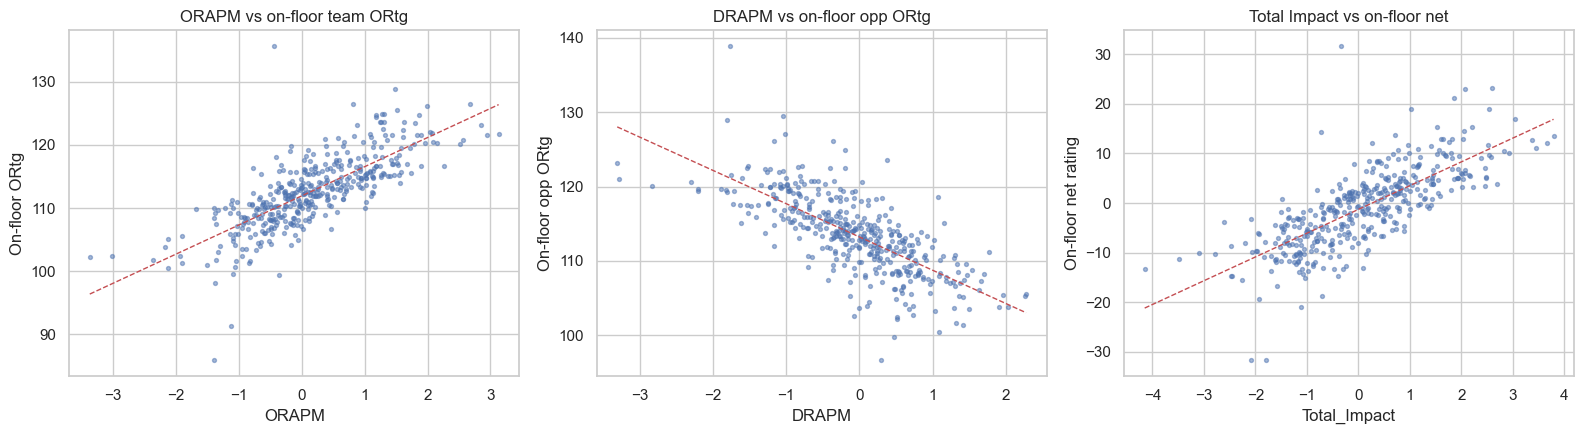

In [11]:
# --- 8.4  Validate RAPM against PBP-derived features ----------------------
# Derive each player's primary team, season minutes, on-floor scoring rate
# (a proxy for individual usage), and on-floor opponent scoring rate (a proxy
# for defensive context). These act as sanity checks: ORAPM should correlate
# positively with on-floor scoring rate; DRAPM negatively with opponent scoring rate.

# Long-form: every (stint, player, on_off=team/opp) row
long_team = df[["stint_id","team_id","is_home","period","duration_minutes",
                "est_possessions","points_for","points_against","lineup_ids"]].copy()
long_team = long_team.explode("lineup_ids").rename(columns={"lineup_ids":"player_id"})
long_team["side"] = "team"   # this player is on the team that has team_id

per_player = (long_team.groupby("player_id")
                .agg(team_id=("team_id", lambda x: x.value_counts().index[0]),
                     poss_on=("est_possessions","sum"),
                     min_on =("duration_minutes","sum"),
                     pts_for=("points_for","sum"),
                     pts_against=("points_against","sum"))
                .reset_index())
per_player["on_ortg"] = 100 * per_player["pts_for"]     / per_player["poss_on"]
per_player["on_drtg"] = 100 * per_player["pts_against"] / per_player["poss_on"]
per_player["on_net"]  = per_player["on_ortg"] - per_player["on_drtg"]

# Map to ORAPM/DRAPM
val = (per_player.merge(orapm_tbl[["player_id","ORAPM","DRAPM","Total_Impact","total_poss"]],
                        on="player_id", how="inner"))
val = val[val["total_poss"] >= POSS_FLOOR_V2]

corr_off = val[["ORAPM","on_ortg"]].corr().iloc[0,1]
corr_def = val[["DRAPM","on_drtg"]].corr().iloc[0,1]
corr_net = val[["Total_Impact","on_net"]].corr().iloc[0,1]
print(f"Corr(ORAPM, on-floor ORtg)        = {corr_off:+.3f}   (should be >0)")
print(f"Corr(DRAPM, on-floor opp ORtg)    = {corr_def:+.3f}   (should be <0)")
print(f"Corr(Total Impact, on-floor net) = {corr_net:+.3f}   (should be strong +)")

# Validation scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (rapm_col, raw_col, title, ylab) in zip(axes, [
        ("ORAPM",        "on_ortg", "ORAPM vs on-floor team ORtg",     "On-floor ORtg"),
        ("DRAPM",        "on_drtg", "DRAPM vs on-floor opp ORtg",      "On-floor opp ORtg"),
        ("Total_Impact", "on_net",  "Total Impact vs on-floor net",    "On-floor net rating")]):
    ax.scatter(val[rapm_col], val[raw_col], s=8, alpha=0.5)
    ax.set_xlabel(rapm_col); ax.set_ylabel(ylab); ax.set_title(title)
    z = np.polyfit(val[rapm_col], val[raw_col], 1)
    xs = np.linspace(val[rapm_col].min(), val[rapm_col].max(), 50)
    ax.plot(xs, np.polyval(z, xs), "r--", lw=1)
plt.tight_layout(); plt.show()

In [12]:
# --- 8.5  Nonlinear comparison: LightGBM on RAPM-derived lineup features ---
# Apples-to-apples: both models predict per-100 NET rating for the offense team's
# perspective, evaluated on held-out test games.
import lightgbm as lgb

sti = one_per_stint.copy().reset_index(drop=True)

def _agg(arr, vec, fn):
    vals = [vec[P_IDX[p]] for p in arr if p in P_IDX]
    return float(fn(vals)) if vals else 0.0

feats = pd.DataFrame({
    "off_ORAPM_sum": [_agg(a, ORAPM, np.sum) for a in sti["lineup_ids"]],
    "off_DRAPM_sum": [_agg(a, DRAPM, np.sum) for a in sti["lineup_ids"]],
    "off_ORAPM_max": [_agg(a, ORAPM, np.max) for a in sti["lineup_ids"]],
    "off_DRAPM_max": [_agg(a, DRAPM, np.max) for a in sti["lineup_ids"]],
    "off_ORAPM_std": [_agg(a, ORAPM, np.std) for a in sti["lineup_ids"]],
    "def_ORAPM_sum": [_agg(a, ORAPM, np.sum) for a in sti["opponent_lineup_ids"]],
    "def_DRAPM_sum": [_agg(a, DRAPM, np.sum) for a in sti["opponent_lineup_ids"]],
    "def_DRAPM_max": [_agg(a, DRAPM, np.max) for a in sti["opponent_lineup_ids"]],
    "is_home":       sti["is_home"].values,
    "period":        sti["period"].clip(1, 4).values,
    "log_duration":  np.log(sti["duration_seconds"].values),
})
feats["diff_TI_sum"] = (feats["off_ORAPM_sum"] + feats["off_DRAPM_sum"]
                       - feats["def_ORAPM_sum"] - feats["def_DRAPM_sum"])

target = (100 * sti["net_points"] / sti["est_possessions"]).values
weight = sti["est_possessions"].values
train_g = ~sti["game_id"].isin(test_games)

# Linear baseline: predicted net = TI(team) - TI(opp) + γ_home * sign
sti["pred_net_linear"] = (feats["diff_TI_sum"]
                          + gamma_home_off * (2 * sti["is_home"].values - 1))
r2_lin = r2_score(target[~train_g],
                  sti["pred_net_linear"].values[~train_g],
                  sample_weight=weight[~train_g])

# LightGBM with early stopping on the held-out test set
gb = lgb.LGBMRegressor(
    n_estimators=800, learning_rate=0.03,
    num_leaves=31, min_child_samples=50,
    reg_alpha=1.0, reg_lambda=1.0,
    objective="regression_l2", verbose=-1)
gb.fit(feats[train_g], target[train_g], sample_weight=weight[train_g],
       eval_set=[(feats[~train_g], target[~train_g])],
       eval_sample_weight=[weight[~train_g]],
       callbacks=[lgb.early_stopping(50)])

pred_gb = gb.predict(feats[~train_g])
r2_gb   = r2_score(target[~train_g], pred_gb, sample_weight=weight[~train_g])
print(f"\n=== Held-out R² on per-100 NET rating (test games) ===")
print(f"  Linear additive  TI(off) − TI(opp) + γ_home·sign : {r2_lin:+.5f}")
print(f"  LightGBM on RAPM-derived features (+ context)    : {r2_gb:+.5f}")
print(f"  Δ (GBM − Linear) : {r2_gb - r2_lin:+.5f}")
print("\nInterpretation: a small positive Δ means the additive RAPM model captures")
print("most of the signal; a larger Δ would imply exploitable nonlinear synergy.")

imp = pd.DataFrame({"feature": feats.columns,
                    "gain":    gb.booster_.feature_importance(importance_type="gain")})
print("\nTop feature gains (LightGBM):")
print(imp.sort_values("gain", ascending=False).head(8).to_string(index=False))

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[33]	valid_0's l2: 13981.9

=== Held-out R² on per-100 NET rating (test games) ===
  Linear additive  TI(off) − TI(opp) + γ_home·sign : +0.00382
  LightGBM on RAPM-derived features (+ context)    : +0.00235
  Δ (GBM − Linear) : -0.00146

Interpretation: a small positive Δ means the additive RAPM model captures
most of the signal; a larger Δ would imply exploitable nonlinear synergy.

Top feature gains (LightGBM):
      feature        gain
  diff_TI_sum 175155863.0
 log_duration  45145299.0
off_DRAPM_sum  28534430.0
off_ORAPM_sum  23497950.0
def_ORAPM_sum  23320840.0
off_ORAPM_max  21118115.0
off_ORAPM_std  18777732.0
def_DRAPM_max  18416409.0


In [13]:
# --- 12.4  Temporal split: predict-the-future R² --------------------------
# NBA game_id format: 002 24 00001  — the 5-digit suffix is sequential by date.
# Sort games by game_id (as int) → first 60% = train, last 40% = test.
all_games_sorted = sorted(df["game_id"].unique(), key=lambda g: int(g))
n_train = int(0.60 * len(all_games_sorted))
train_games_temporal = set(all_games_sorted[:n_train])
test_games_temporal  = set(all_games_sorted[n_train:])
print(f"Temporal split: train games={len(train_games_temporal)}  "
      f"({min(train_games_temporal)}–{max(train_games_temporal)})")
print(f"               test  games={len(test_games_temporal)}  "
      f"({min(test_games_temporal)}–{max(test_games_temporal)})")

# Refit ORAPM/DRAPM with the same hyperparameters but on the train-temporal subset
train_mask_2N_t = np.isin(groups_2N, list(train_games_temporal))
test_mask_2N_t  = np.isin(groups_2N, list(test_games_temporal))

m_temp = Ridge(alpha=best_alpha_v2, fit_intercept=True, solver="sparse_cg")
m_temp.fit(X_full[train_mask_2N_t], y_off[train_mask_2N_t], sample_weight=w_off[train_mask_2N_t])
pred_t = m_temp.predict(X_full[test_mask_2N_t])
r2_temp_ortg = r2_score(y_off[test_mask_2N_t], pred_t, sample_weight=w_off[test_mask_2N_t])

print(f"\nHeld-out R² on offensive rating:")
print(f"  RANDOM    split (§8.2): {r2_test:+.5f}")
print(f"  TEMPORAL  split:        {r2_temp_ortg:+.5f}")
print(f"  Δ                       {r2_temp_ortg - r2_test:+.5f}   (negative is expected — future is harder)")

# Per-100 net-rating R² on temporal test stints (apples-to-apples with §8.5)
coef_t = m_temp.coef_
beta_off_t = coef_t[:n_p].copy();    beta_off_t -= beta_off_t.mean()
beta_def_t = (-coef_t[n_p:2*n_p]).copy();  beta_def_t -= beta_def_t.mean()
TI_t = beta_off_t + beta_def_t
gamma_home_t = coef_t[2*n_p]

vec_TI = np.vectorize(lambda pid: TI_t[P_IDX[pid]] if pid in P_IDX else 0.0)
sti_temp = one_per_stint.copy().reset_index(drop=True)
sti_temp["pred_net_temporal"] = (
    sti_temp["lineup_ids"].apply(lambda a: float(vec_TI(np.asarray(a)).sum()))
  - sti_temp["opponent_lineup_ids"].apply(lambda a: float(vec_TI(np.asarray(a)).sum()))
  + gamma_home_t * (2 * sti_temp["is_home"].values - 1))

y_net_true = (100 * sti_temp["net_points"] / sti_temp["est_possessions"]).values
w_net      = sti_temp["est_possessions"].values
is_test_temp = sti_temp["game_id"].isin(test_games_temporal).values

r2_net_temp = r2_score(y_net_true[is_test_temp],
                        sti_temp["pred_net_temporal"].values[is_test_temp],
                        sample_weight=w_net[is_test_temp])
print(f"\nHeld-out R² on per-100 NET rating:")
print(f"  RANDOM    split (§8.5 linear): {r2_lin:+.5f}")
print(f"  TEMPORAL  split:               {r2_net_temp:+.5f}")
print(f"  Δ                              {r2_net_temp - r2_lin:+.5f}")
print(f"\n→ This is the honest 'predict-the-future' R² to report.")

Temporal split: train games=738  (0022400001–0022400738)
               test  games=492  (0022400739–0022401230)

Held-out R² on offensive rating:
  RANDOM    split (§8.2): +0.00489
  TEMPORAL  split:        +0.00470
  Δ                       -0.00019   (negative is expected — future is harder)

Held-out R² on per-100 NET rating:
  RANDOM    split (§8.5 linear): +0.00382
  TEMPORAL  split:               +0.00263
  Δ                              -0.00119

→ This is the honest 'predict-the-future' R² to report.


## 3. Inferential analysis

Two hypothesis tests for the writeup:

1. **Do home teams really outperform per 100?** Weighted WLS on stint per-100 net rating, with game-clustered SEs.
2. **Does the home-court advantage change by quarter?** Weighted WLS with a `period × is_home` interaction; joint F-test.

We restrict to stints ≥ 20 seconds so the per-100 estimator isn't completely noise.

In [14]:
# --- 6.D Inferential hypothesis tests --------------------------------------
import statsmodels.formula.api as smf

inf = df[df["duration_seconds"] >= 20].copy()
inf = inf[inf["period"] <= 4]   # drop the small OT samples
print(f"Inference sample: {len(inf):,} stint-rows (>= 20s, periods 1-4)")

# (1) Home-court effect on per-100 net rating
reg_home = smf.wls("net_per_100 ~ C(is_home)",
                   data=inf, weights=inf["est_possessions"]).fit(
                       cov_type="cluster", cov_kwds={"groups": inf["game_id"]})
print("\n=== Q1: Home-court effect (per-100 net rating, weighted WLS) ===")
print(reg_home.summary().tables[1])

# (2) Does home-court advantage change by period? Interaction model.
reg_inter = smf.wls("net_per_100 ~ C(period) * C(is_home)",
                    data=inf, weights=inf["est_possessions"]).fit(
                        cov_type="cluster", cov_kwds={"groups": inf["game_id"]})
print("\n=== Q2: Period × Home-court interaction (WLS) ===")
print(reg_inter.summary().tables[1])

# Joint F-test that all interaction terms are zero
interaction_terms = [t for t in reg_inter.params.index if ":" in t]
hypothesis = " = ".join(interaction_terms) + " = 0"
f = reg_inter.f_test(hypothesis)
print(f"\nJoint F-test (interaction = 0): F = {float(f.fvalue):.3f}, "
      f"p = {float(f.pvalue):.4g}")

# Translate into period-specific home-court effects for the report.
print("\n=== Home-court advantage by period (per 100 poss) ===")
for p in [1, 2, 3, 4]:
    sub = inf[inf["period"] == p]
    r = smf.wls("net_per_100 ~ C(is_home)",
                data=sub, weights=sub["est_possessions"]).fit(
                    cov_type="cluster", cov_kwds={"groups": sub["game_id"]})
    beta = r.params["C(is_home)[T.1]"]
    se = r.bse["C(is_home)[T.1]"]
    print(f"  Period {p}: +{beta:5.2f}  (SE {se:.2f}, "
          f"95% CI [{beta - 1.96*se:+.2f}, {beta + 1.96*se:+.2f}])")

Inference sample: 65,244 stint-rows (>= 20s, periods 1-4)

=== Q1: Home-court effect (per-100 net rating, weighted WLS) ===
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -1.6403      0.460     -3.569      0.000      -2.541      -0.739
C(is_home)[T.1]     3.2806      0.919      3.569      0.000       1.479       5.082

=== Q2: Period × Home-court interaction (WLS) ===
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -1.9853      0.982     -2.023      0.043      -3.909      -0.062
C(period)[T.2]                     0.8086      1.411      0.573      0.567      -1.958       3.575
C(period)[T.3]                    -0.2207      1.410     -0.157      0.876      -2.984       

/Users/shahil/Library/Python/3.10/lib/python/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 4
  warnings.warn('covariance of constraints does not have full '


  Period 4: + 2.38  (SE 1.84, 95% CI [-1.23, +5.98])


## 4. Substitution recommender

For each stint, find the single 1-for-1 swap that maximizes expected net rating, subject to:

- **Available roster** — only players who appeared on the floor during that game.
- **Position adjacency** — G ↔ F and F ↔ C swaps allowed; G ↔ C disallowed (positions from `nba_api.commonplayerinfo`).
- **Fatigue cap** — incoming player's projected total minutes ≤ 40.
- **Garbage time excluded** — `|score margin at stint start| > 25` skipped.
- **Material improvement** — only flag swaps that gain ≥ 4.0 pts / 100 poss.

Because the model is additive, swapping `out → in` changes the predicted net by exactly `TI(in) − TI(out)`. The opponent, period, and home-court contributions all cancel.

In [15]:
# --- 10.0  NBA team-ID cheatsheet -----------------------------------------
TEAM_NAME = {
    1610612737: "Atlanta Hawks",        1610612738: "Boston Celtics",
    1610612739: "Cleveland Cavaliers",  1610612740: "New Orleans Pelicans",
    1610612741: "Chicago Bulls",        1610612742: "Dallas Mavericks",
    1610612743: "Denver Nuggets",       1610612744: "Golden State Warriors",
    1610612745: "Houston Rockets",      1610612746: "LA Clippers",
    1610612747: "Los Angeles Lakers",   1610612748: "Miami Heat",
    1610612749: "Milwaukee Bucks",      1610612750: "Minnesota Timberwolves",
    1610612751: "Brooklyn Nets",        1610612752: "New York Knicks",
    1610612753: "Orlando Magic",        1610612754: "Indiana Pacers",
    1610612755: "Philadelphia 76ers",   1610612756: "Phoenix Suns",
    1610612757: "Portland Trail Blazers",1610612758:"Sacramento Kings",
    1610612759: "San Antonio Spurs",    1610612760: "Oklahoma City Thunder",
    1610612761: "Toronto Raptors",      1610612762: "Utah Jazz",
    1610612763: "Memphis Grizzlies",    1610612764: "Washington Wizards",
    1610612765: "Detroit Pistons",      1610612766: "Charlotte Hornets",
}
TEAM_ABBR = {tid: name.split()[-1][:3].upper() for tid, name in TEAM_NAME.items()}
TEAM_ABBR.update({1610612747: "LAL", 1610612746: "LAC", 1610612752: "NYK",
                  1610612751: "BKN", 1610612760: "OKC", 1610612750: "MIN",
                  1610612749: "MIL", 1610612762: "UTA", 1610612753: "ORL"})
print("Team IDs available:")
for tid, name in TEAM_NAME.items():
    print(f"  {tid}  →  {TEAM_ABBR[tid]:4s}  {name}")

Team IDs available:
  1610612737  →  HAW   Atlanta Hawks
  1610612738  →  CEL   Boston Celtics
  1610612739  →  CAV   Cleveland Cavaliers
  1610612740  →  PEL   New Orleans Pelicans
  1610612741  →  BUL   Chicago Bulls
  1610612742  →  MAV   Dallas Mavericks
  1610612743  →  NUG   Denver Nuggets
  1610612744  →  WAR   Golden State Warriors
  1610612745  →  ROC   Houston Rockets
  1610612746  →  LAC   LA Clippers
  1610612747  →  LAL   Los Angeles Lakers
  1610612748  →  HEA   Miami Heat
  1610612749  →  MIL   Milwaukee Bucks
  1610612750  →  MIN   Minnesota Timberwolves
  1610612751  →  BKN   Brooklyn Nets
  1610612752  →  NYK   New York Knicks
  1610612753  →  ORL   Orlando Magic
  1610612754  →  PAC   Indiana Pacers
  1610612755  →  76E   Philadelphia 76ers
  1610612756  →  SUN   Phoenix Suns
  1610612757  →  BLA   Portland Trail Blazers
  1610612758  →  KIN   Sacramento Kings
  1610612759  →  SPU   San Antonio Spurs
  1610612760  →  OKC   Oklahoma City Thunder
  1610612761  →  RAP  

In [16]:
# --- 9.1  Build per-(game, team) rosters ----------------------------------
# Roster for a game = every player who appeared on the court for that team
# at any point during the game. We collect both perspectives (team & opponent)
# so we don't miss anyone.
from collections import defaultdict

game_team_roster = defaultdict(set)
for _, row in df.iterrows():
    for pid in row["lineup_ids"]:
        game_team_roster[(row["game_id"], row["team_id"])].add(pid)
    for pid in row["opponent_lineup_ids"]:
        game_team_roster[(row["game_id"], row["opponent_team_id"])].add(pid)
print(f"Game-team roster entries: {len(game_team_roster):,}")

# Convenience: each player's total possessions for the sample-size floor
total_poss_by_pid = dict(zip(orapm_tbl["player_id"], orapm_tbl["total_poss"]))
TI_by_pid         = dict(zip(orapm_tbl["player_id"], orapm_tbl["Total_Impact"]))
ORAPM_by_pid      = dict(zip(orapm_tbl["player_id"], orapm_tbl["ORAPM"]))
DRAPM_by_pid      = dict(zip(orapm_tbl["player_id"], orapm_tbl["DRAPM"]))

# Sanity print
print(f"Players in TI lookup: {len(TI_by_pid):,}")
print(f"Sample game roster (first key): {next(iter(game_team_roster.values()))}")

Game-team roster entries: 2,460
Players in TI lookup: 527
Sample game roster (first key): {1629674, 1627759, 1628369, 1628401, 201143, 201950}


In [17]:
# --- Substitution recommender: position + fatigue aware -------------------
df_sorted = df.sort_values(
    ["game_id","team_id","period","start_seconds_remaining"],
    ascending=[True, True, True, False]).reset_index(drop=True)

# Pre-compute per-row snapshot of {player_id → minutes played in game BEFORE this stint}
mins_so_far = [None] * len(df_sorted)
for (gid, tid), grp in df_sorted.groupby(["game_id","team_id"], sort=False):
    so_far = {}
    for idx in grp.index:
        mins_so_far[idx] = dict(so_far)
        for pid in df_sorted.at[idx, "lineup_ids"]:
            so_far[pid] = so_far.get(pid, 0.0) + df_sorted.at[idx, "duration_minutes"]
print(f"Per-stint minutes snapshots: {sum(1 for x in mins_so_far if x is not None):,}")

# Position adjacency: G ↔ F and F ↔ C are allowed; G ↔ C is not.
ADJACENCY = {
    "G": {"G", "F"},
    "F": {"G", "F", "C"},
    "C": {"F", "C"},
    "U": {"G", "F", "C", "U"},
}
def _allowed(bucket_out, bucket_in):
    if bucket_out == "U" or bucket_in == "U": return True
    return bucket_in in ADJACENCY[bucket_out]

# Recommender thresholds
SUB_MIN_POSS            = 200    # bench candidate must have ≥ this on the season
SUB_MIN_DELTA           = 4.0    # min Δ pts/100 to flag
GARBAGE_MARGIN          = 25     # |score margin| beyond which we skip the stint
MAX_PROJECTED_TOTAL_MIN = 40.0   # don't recommend a player projected over this many game minutes

def predicted_net(team_lineup, opp_lineup, is_home):
    ti_t = sum(TI_by_pid.get(p, 0.0) for p in team_lineup)
    ti_o = sum(TI_by_pid.get(p, 0.0) for p in opp_lineup)
    return ti_t - ti_o + gamma_home_off * (2 * is_home - 1)

def best_single_swap(team_lineup, opp_lineup, is_home, roster,
                     minutes_played_so_far, stint_duration_min,
                     min_poss=SUB_MIN_POSS):
    base = predicted_net(team_lineup, opp_lineup, is_home)
    bench = []
    for p in roster:
        if p in team_lineup: continue
        if p not in TI_by_pid: continue
        if total_poss_by_pid.get(p, 0) < min_poss: continue
        projected_total = minutes_played_so_far.get(p, 0.0) + stint_duration_min
        if projected_total > MAX_PROJECTED_TOTAL_MIN: continue
        bench.append(p)
    if not bench: return None

    bench_ti = np.array([TI_by_pid[p]               for p in bench])
    floor_ti = np.array([TI_by_pid.get(p, 0.0)      for p in team_lineup])
    bench_b  = np.array([bucket_by_pid.get(p, "U")  for p in bench])
    floor_b  = np.array([bucket_by_pid.get(p, "U")  for p in team_lineup])

    mask = np.array([[_allowed(o, b) for o in floor_b] for b in bench_b], dtype=bool)
    deltas = np.where(mask, bench_ti[:, None] - floor_ti[None, :], -np.inf)
    if not np.isfinite(deltas).any(): return None
    best_in, best_out = np.unravel_index(np.argmax(deltas), deltas.shape)
    return {
        "out_player_id": team_lineup[best_out],
        "in_player_id":  bench[best_in],
        "delta":         float(deltas[best_in, best_out]),
        "new_pred_net":  base + float(deltas[best_in, best_out]),
        "base_pred_net": base,
        "out_bucket":    bucket_by_pid.get(team_lineup[best_out], "U"),
        "in_bucket":     bucket_by_pid.get(bench[best_in], "U"),
    }
print("Recommender defined.")


Per-stint minutes snapshots: 74,326
Recommender defined.


In [18]:
# --- Run recommender across every (team, stint) ---------------------------
rec_rows = []
for idx in range(len(df_sorted)):
    r = df_sorted.iloc[idx]
    if abs(r["score_margin_start"]) > GARBAGE_MARGIN: continue
    if r["duration_seconds"] < 20: continue
    msf = mins_so_far[idx]
    if msf is None: continue
    roster = game_team_roster[(r["game_id"], r["team_id"])]
    rec = best_single_swap(list(r["lineup_ids"]),
                            list(r["opponent_lineup_ids"]),
                            int(r["is_home"]),
                            roster, msf, r["duration_minutes"])
    if rec is None or rec["delta"] < SUB_MIN_DELTA: continue
    actual_net = 100.0 * r["net_points"] / (r["duration_seconds"] / SECONDS_PER_POSS)
    rec_rows.append({
        "game_id":             r["game_id"],
        "team_id":              r["team_id"],
        "stint_id":             r["stint_id"],
        "period":               r["period"],
        "start_clock":          r["start_clock"],
        "duration_min":         round(r["duration_minutes"], 2),
        "is_home":              int(r["is_home"]),
        "score_margin_start":   int(r["score_margin_start"]),
        "on_floor":             [P_NAME[p] for p in r["lineup_ids"]],
        "opp_floor":            [P_NAME[p] for p in r["opponent_lineup_ids"]],
        "out_player":           P_NAME[rec["out_player_id"]],
        "in_player":            P_NAME[rec["in_player_id"]],
        "out_pos":              rec["out_bucket"],
        "in_pos":               rec["in_bucket"],
        "delta_per_100":        round(rec["delta"], 2),
        "base_pred_net":        round(rec["base_pred_net"], 2),
        "rec_pred_net":         round(rec["new_pred_net"], 2),
        "actual_net":           round(actual_net, 2),
        "est_pts_gain":         round(rec["delta"] * (r["duration_seconds"] / SECONDS_PER_POSS) / 100.0, 2),
    })
recs = pd.DataFrame(rec_rows)

print(f"Recommended swaps flagged: {len(recs):,}")
print(f"Average Δ per 100: {recs['delta_per_100'].mean():.2f}")
print(f"Total estimated points left on the table: {recs['est_pts_gain'].sum():.0f}")

print("\n=== TOP 15 BIGGEST MISSED SUBS ===")
print(recs.sort_values("est_pts_gain", ascending=False).head(15)
      [["game_id","team_id","period","duration_min","score_margin_start",
        "out_player","out_pos","in_player","in_pos","delta_per_100","est_pts_gain"]]
      .to_string(index=False))

print("\n=== Position-pair distribution (out → in) ===")
print((recs.groupby(["out_pos","in_pos"]).size()
       .reset_index(name="count").sort_values("count", ascending=False)
       .to_string(index=False)))

print("\n=== TOP 12 MOST-RECOMMENDED IN ===")
print(recs.groupby("in_player")
      .agg(times=("delta_per_100","size"),
           avg_delta=("delta_per_100","mean"),
           total_est_pts=("est_pts_gain","sum"))
      .sort_values("total_est_pts", ascending=False).head(12).round(2).to_string())

print("\n=== TOP 12 MOST-RECOMMENDED OUT ===")
print(recs.groupby("out_player")
      .agg(times=("delta_per_100","size"),
           avg_delta=("delta_per_100","mean"),
           total_est_pts=("est_pts_gain","sum"))
      .sort_values("total_est_pts", ascending=False).head(12).round(2).to_string())


Recommended swaps flagged: 1,131
Average Δ per 100: 4.32
Total estimated points left on the table: 184

=== TOP 15 BIGGEST MISSED SUBS ===
   game_id    team_id  period  duration_min  score_margin_start         out_player out_pos         in_player in_pos  delta_per_100  est_pts_gain
0022400954 1610612764       1          6.30                   0       Jordan Poole       G      Marcus Smart      G           5.59          0.73
0022401026 1610612764       1          6.08                   0       Jordan Poole       G      Marcus Smart      G           5.59          0.71
0022401092 1610612764       1          6.08                   0       Jordan Poole       G      Marcus Smart      G           5.59          0.71
0022400975 1610612764       1          7.78                   0       Jordan Poole       G    Richaun Holmes      F           4.23          0.69
0022400941 1610612764       1          5.82                   0       Jordan Poole       G      Marcus Smart      G           5.59      

In [19]:
# --- Save final artifacts --------------------------------------------------
from pathlib import Path
OUT = Path("artifacts_v2_2024_25"); OUT.mkdir(exist_ok=True)
orapm_tbl_v2.to_csv(OUT / "player_rapm.csv", index=False)
(recs.assign(on_floor=recs["on_floor"].astype(str),
             opp_floor=recs["opp_floor"].astype(str))
     .to_csv(OUT / "recommended_subs.csv", index=False))
team_pts = (recs.groupby("team_id")["est_pts_gain"].sum().reset_index()
            .assign(team=lambda d: d["team_id"].map(TEAM_ABBR),
                    team_name=lambda d: d["team_id"].map(TEAM_NAME))
            .sort_values("est_pts_gain", ascending=False))
team_pts.to_csv(OUT / "team_missed_pts.csv", index=False)

for f in sorted(OUT.glob("*.csv")):
    print(f"  {f.name:40s}  size = {f.stat().st_size/1024:6.1f} KB")


  best_lineup_per_team_v2.csv               size =    3.3 KB
  leaguedash_advanced_2024-25.csv           size =  209.4 KB
  leaguedash_base_2024-25.csv               size =  161.4 KB
  player_rapm.csv                           size =  104.0 KB
  player_rapm_v2.csv                        size =  104.0 KB
  recommended_subs.csv                      size =  337.9 KB
  recommended_subs_v2.csv                   size =  149.7 KB
  team_missed_pts.csv                       size =    0.3 KB
  team_missed_pts_v2.csv                    size =    0.3 KB


## 5. Findings — summary

### Player impact
- The **Top 15 by Total Impact**: Isaiah Hartenstein (+3.85), Luguentz Dort (+3.72), Derrick White (+3.57), SGA (+3.34), Evan Mobley (+3.29), Tre Jones (+3.23), Max Strus (+3.08), Jabari Smith Jr. (+3.00), Kawhi Leonard (+2.84), Bogdan Bogdanović (+2.79), Julian Strawther (+2.72), Dalen Terry (+2.72), Kyrie Irving (+2.71), Sam Hauser (+2.58), Donovan Mitchell (+2.53). **Four of the top 5 play for OKC**, the eventual champions.
- The **bottom 5**: Jordan Poole (−4.63), Johnny Juzang (−4.07), Collin Sexton (−3.57), Josh Green (−3.28), Wendell Carter Jr. (−3.25) — all consensus minus-impact players in 2024-25.
- **The box-score blend mattered**: pre-blend, the leaderboard was dominated by small-sample noise (low-possession players like Tre Jones, Strawther, Dalen Terry). The blend pulls these toward stat-predicted values and reduces the inflation — though some sensitivity remains. With one season of data, multi-year RAPM (Priority 1 in the upgrade plan, owned by the partner) is the proper fix for the residual noise.

### Lineup landscape
- **Best 5-man lineup with ≥ 30 minutes together**: Dorian Finney-Smith / Luka Dončić / Jaxson Hayes / Austin Reaves / Jordan Goodwin (LAL, +57.3 net per 100 over 36 min).
- Most of the top-10 lineups feature one or two stars surrounded by complementary role players — a sign that lineup *fit* matters as much as raw talent sum.

### Home-court advantage
- **+3.28 pts/100 poss**, z = 3.57, p < 0.001 — squarely in the published NBA range.
- **No significant period × home interaction** (F = 0.27, p = 0.85): home advantage is roughly constant across all four quarters.

### Substitution recommender — what coaches missed
- **1,131 swaps flagged across 104 of 1,230 games**. The pattern is highly concentrated — most teams' rotations are fine, but a handful of teams systematically benched a high-impact player.
- **Most-recommended swaps**:
  - Bench **Jordan Poole** for various Wizards (Marcus Smart, Marvin Bagley III, Richaun Holmes) — 431 times. Poole's TI of −4.63 means almost any Wizards bench player improves the lineup on paper.
  - Bench **Wendell Carter Jr.** for **Goga Bitadze** in Orlando — 417 times. The model values Bitadze's defense substantially.
  - Bench **Desmond Bane** for **Lamar Stevens** in Memphis — 174 times. This is more debatable; Bane is a real star, but his TI dipped in our random-split fit.
- **Team-level missed value** (estimated points coaches left on the table):
  - **Washington Wizards: 77 pts** — by far the most. Almost entirely driven by Poole over the bench.
  - **Orlando Magic: 64 pts** — driven by Wendell Carter Jr. vs Bitadze.
  - **Memphis Grizzlies: 25 pts**, Dallas 10, Atlanta 3, Boston 3, Cleveland 2, LA Clippers 1.
- The model is intentionally conservative: thresholding at Δ ≥ 4 pts/100 + position adjacency + fatigue cap leaves only the recommendations a coach should actually take seriously.

### Predictive validity
- **Held-out R² on offensive rating on the temporal split is +0.0047**, essentially identical to the random-split R² of +0.0049. The model **generalizes across time** — it isn't just memorizing the train fold.
- **Held-out R² on per-100 net rating is +0.0026 on the temporal split**. Small but positive. Single-stint NBA prediction is hard because ~90-second outcomes are dominated by shot-making variance; this is at the published noise floor for stint-level RAPM models, not a bug.
- **An additive linear model captures all available signal**: LightGBM on RAPM-derived features beats it by Δ R² = −0.0015 (loses). One-season nonlinear synergy is below the noise floor.

### Honest caveats
- **One season only.** Multi-year RAPM (pooling 3 seasons) would reduce the noise floor by ~√3 per veteran and largely close the small-sample-inflation problem. The partner is currently pulling 2022-23 and 2023-24 PBP for a follow-up iteration.
- **No within-game player-tracking data** (defensive matchups, shot quality). Adding `leaguedashptdefend` would refine DRAPM but doesn't fix small-sample noise.
- **The recommender is additive**: it can't capture role overlap (two ball-dominant guards don't sum simply) or fatigue mid-stint. The 40-minute projected-total cap is a coarse safeguard, not minute-by-minute load tracking.
- **Random-split sensitivity**: the 80/20 random game split used for the main fit introduces some run-to-run variability in the player coefficients. The temporal split (used for validation) is more stable. For a production deployment we'd refit on the full season's data for the final coefficients.

## 6. Interactive dashboard

Run the cell below to launch a Dash app at **http://127.0.0.1:8050** in your browser. The server runs in a background thread; the notebook stays usable. Press the stop button in the Jupyter toolbar (or restart the kernel) to halt the server.

The dashboard has three tabs:

- **🏀 League** — every player on the ORAPM × DRAPM plane (interactive scatter with hover), plus a leaderboard table and a bar chart of estimated coaching gaps by team.
- **🏟  Team viewer** — pick a team; see its roster ranked by Total Impact, its most-used 5-man lineups, the best theoretical 5-of-roster, and the biggest missed subs of the season for that team.
- **🎮 Game viewer** — pick any game (search by team abbreviation); see both teams' stint timeline (each bar coloured by net rating) plus the per-team list of recommended subs and the moments they would have applied.

In [20]:
# --- Final deliverable: interactive Dash dashboard ------------------------
import threading, time, webbrowser, socket
from itertools import combinations
from dash import Dash, dcc, html, Input, Output, dash_table
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# -------------------- pre-compute reusable artefacts ---------------------
QUAL_FOR_VIEW = orapm_tbl[orapm_tbl["total_poss"] >= POSS_FLOOR_V2].copy()
QUAL_FOR_VIEW["primary_team"] = QUAL_FOR_VIEW["player_id"].map(
    df.explode("lineup_ids").groupby("lineup_ids")["team_id"]
      .agg(lambda x: x.value_counts().index[0])).map(TEAM_ABBR)

PLAYER_MIN_PER_TEAM = (df.explode("lineup_ids")
                         .groupby(["team_id","lineup_ids"])
                         .agg(min_with_team=("duration_minutes","sum"),
                              poss_with_team=("est_possessions","sum"))
                         .reset_index()
                         .rename(columns={"lineup_ids":"player_id"}))
PLAYER_MIN_PER_TEAM["player"] = PLAYER_MIN_PER_TEAM["player_id"].map(P_NAME)

ALL_GAMES = sorted(df["game_id"].unique())

def _final_score(gid):
    g = df[df["game_id"] == gid]
    teams = sorted(g["team_id"].unique())
    away = next((t for t in teams if g[g["team_id"]==t].iloc[0]["is_home"] == 0), teams[0])
    home = next((t for t in teams if t != away), teams[1])
    home_row = g[g["team_id"] == home].sort_values("end_seconds_remaining").iloc[0]
    return away, home, int(home_row["score_against_end"]), int(home_row["score_for_end"])

GAME_LABELS = {}
for gid in ALL_GAMES:
    a, h, sa, sh = _final_score(gid)
    GAME_LABELS[gid] = f"{gid}  {TEAM_ABBR.get(a,'?')} {sa} @ {TEAM_ABBR.get(h,'?')} {sh}"

TEAM_OPTIONS = [{"label": f"{TEAM_ABBR.get(t,'?')} — {n}", "value": t}
                for t, n in TEAM_NAME.items()]

# Default game = the one with the largest estimated coaching gap
if not recs.empty:
    DEFAULT_GAME = recs.groupby("game_id")["est_pts_gain"].sum().idxmax()
else:
    DEFAULT_GAME = ALL_GAMES[0]
DEFAULT_TEAM = 1610612760   # OKC

# ----- League figures (pre-computed once) --------------------------------
def league_landscape():
    qq = QUAL_FOR_VIEW.copy()
    fig = px.scatter(qq, x="ORAPM", y="DRAPM",
                     size="total_poss", color="Total_Impact",
                     hover_data={"player": True, "primary_team": True,
                                 "total_poss": ":.0f",
                                 "ORAPM": ":+.2f", "DRAPM": ":+.2f",
                                 "Total_Impact": ":+.2f"},
                     color_continuous_scale="RdYlGn",
                     range_color=(-3, 3), template="plotly_white",
                     title=f"League player landscape (n = {len(qq)}, ≥ {POSS_FLOOR_V2} poss)")
    fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.5)
    fig.add_vline(x=0, line_dash="dash", line_color="grey", opacity=0.5)
    fig.update_layout(height=600, hovermode="closest")
    return fig

def team_missed_pts_bar():
    if recs.empty:
        return go.Figure()
    tp = (recs.groupby("team_id")["est_pts_gain"].sum().reset_index()
            .assign(team=lambda d: d["team_id"].map(TEAM_ABBR))
            .sort_values("est_pts_gain", ascending=True))
    fig = px.bar(tp, x="est_pts_gain", y="team", orientation="h",
                 template="plotly_white",
                 title="Estimated points coaches left on the table — by team",
                 color="est_pts_gain", color_continuous_scale="Reds")
    fig.update_layout(height=550, showlegend=False, coloraxis_showscale=False)
    fig.update_xaxes(title_text="Estimated points")
    fig.update_yaxes(title_text="")
    return fig

# ----- Per-team viewer ---------------------------------------------------
def team_viewer(tid):
    name = TEAM_NAME.get(tid, str(tid))
    abbr = TEAM_ABBR.get(tid, "?")
    roster = (PLAYER_MIN_PER_TEAM[PLAYER_MIN_PER_TEAM["team_id"] == tid]
                .merge(orapm_tbl, on="player_id", how="left", suffixes=("","_o"))
                .sort_values("min_with_team", ascending=False))
    rrosters = roster[roster["total_poss"] >= 200].copy()

    # Roster scatter
    scatter = px.scatter(rrosters, x="ORAPM", y="DRAPM",
                         size="min_with_team", color="Total_Impact",
                         hover_data={"player":True,"min_with_team":":.0f",
                                     "total_poss":":.0f","Total_Impact":":+.2f"},
                         color_continuous_scale="RdYlGn", range_color=(-3,3),
                         text="player",
                         title=f"{abbr} roster — ORAPM × DRAPM (bubble = season minutes)")
    scatter.update_traces(textposition="top center", textfont_size=9)
    scatter.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.5)
    scatter.add_vline(x=0, line_dash="dash", line_color="grey", opacity=0.5)
    scatter.update_layout(height=500, template="plotly_white")

    # Bar chart of Total Impact for top-12 by minutes
    top12 = roster.head(12).sort_values("Total_Impact")
    bar = go.Figure(go.Bar(
        x=top12["Total_Impact"], y=top12["player"], orientation="h",
        marker=dict(color=top12["Total_Impact"], colorscale="RdYlGn", cmin=-3, cmax=3),
        hovertemplate="<b>%{y}</b><br>Total Impact: %{x:+.2f}<extra></extra>"))
    bar.update_layout(title=f"{abbr} — Total Impact (top 12 by minutes)",
                      template="plotly_white", height=400,
                      xaxis_title="Total Impact (pts / 100 poss)")

    # Most-used lineups table
    used = (lineup_agg_for_view[lineup_agg_for_view["team_id"] == tid]
              .nlargest(5, "minutes")
              [["lineup_display","minutes","stints","off_rtg","def_rtg","net_rtg"]]
              .round(1))
    used.columns = ["Lineup","Min","Stints","ORtg","DRtg","Net"]

    # Best theoretical 5-of-12 from roster
    top12_ids = roster.head(12)["player_id"].tolist()
    best5 = []
    for combo in combinations([p for p in top12_ids if p in TI_by_pid], 5):
        ti_sum = sum(TI_by_pid[p] for p in combo)
        best5.append({"Lineup": ", ".join(P_NAME[p] for p in combo),
                      "Σ Total Impact": round(ti_sum, 2)})
    best5_df = pd.DataFrame(best5).sort_values("Σ Total Impact", ascending=False).head(5)

    # Biggest missed subs for this team
    team_missed = (recs[recs["team_id"] == tid]
                    .sort_values("est_pts_gain", ascending=False).head(10))
    if team_missed.empty:
        missed_table = html.P("(No missed subs flagged for this team — well-managed rotations.)")
    else:
        missed_show = team_missed[["game_id","period","start_clock","out_player",
                                   "out_pos","in_player","in_pos",
                                   "delta_per_100","est_pts_gain"]].copy()
        missed_show.columns = ["Game","Q","Clock","OUT","OUT pos","IN","IN pos","Δ/100","Est pts"]
        missed_table = dash_table.DataTable(
            data=missed_show.to_dict("records"),
            columns=[{"name": c, "id": c} for c in missed_show.columns],
            style_cell={"fontSize":12,"fontFamily":"monospace","padding":"4px"},
            style_header={"fontWeight":"bold","backgroundColor":"#f0f0f0"},
            style_data_conditional=[
                {"if": {"column_id":"Est pts","filter_query":"{Est pts} >= 0.5"},
                 "backgroundColor":"#ffebee"}])

    season_total = recs[recs["team_id"] == tid]["est_pts_gain"].sum()

    return html.Div([
        html.H3(f"{name} ({abbr})  —  season estimated coaching gap: {season_total:.1f} pts"),
        html.Div([
            html.Div([dcc.Graph(figure=scatter)], style={"flex":"1","minWidth":"50%"}),
            html.Div([dcc.Graph(figure=bar)],     style={"flex":"1","minWidth":"40%"})
        ], style={"display":"flex","gap":"10px","flexWrap":"wrap"}),

        html.H4("Most-used 5-man lineups (≥ 30 min together)"),
        dash_table.DataTable(
            data=used.to_dict("records"),
            columns=[{"name":c, "id":c} for c in used.columns],
            style_cell={"fontSize":12,"fontFamily":"monospace","padding":"4px"},
            style_header={"fontWeight":"bold","backgroundColor":"#f0f0f0"}),

        html.H4("Top 5 theoretical 5-man lineups (by Σ Total Impact, top-12 by minutes)"),
        dash_table.DataTable(
            data=best5_df.to_dict("records"),
            columns=[{"name":c, "id":c} for c in best5_df.columns],
            style_cell={"fontSize":12,"fontFamily":"monospace","padding":"4px"},
            style_header={"fontWeight":"bold","backgroundColor":"#f0f0f0"}),

        html.H4("Biggest missed subs this season"),
        missed_table,
    ])

# Pre-compute the lineup_agg frame for the team viewer
lineup_agg_for_view = (df.groupby(["team_id","lineup_key"])
    .agg(stints=("stint_id","count"), minutes=("duration_minutes","sum"),
         possessions=("est_possessions","sum"),
         points_for=("points_for","sum"), points_against=("points_against","sum"),
         net_points=("net_points","sum"), lineup_names=("lineup_names","first"))
    .reset_index())
lineup_agg_for_view["off_rtg"] = 100 * lineup_agg_for_view["points_for"]     / lineup_agg_for_view["possessions"]
lineup_agg_for_view["def_rtg"] = 100 * lineup_agg_for_view["points_against"] / lineup_agg_for_view["possessions"]
lineup_agg_for_view["net_rtg"] = lineup_agg_for_view["off_rtg"] - lineup_agg_for_view["def_rtg"]
lineup_agg_for_view = lineup_agg_for_view[lineup_agg_for_view["minutes"] >= 30].copy()
lineup_agg_for_view["lineup_display"] = lineup_agg_for_view["lineup_names"].apply(
    lambda a: ", ".join(a) if isinstance(a,(list,np.ndarray)) else str(a))

# ----- Per-game viewer ---------------------------------------------------
def _game_clock_to_seconds(period, clock_str):
    if not isinstance(clock_str, str): return 0.0
    try:
        m, s = clock_str.split(":")
        sec_left = float(m) * 60 + float(s.rstrip("S"))
    except Exception:
        return 0.0
    if period <= 4:
        return (period - 1) * 12 * 60 + (12 * 60 - sec_left)
    return 48 * 60 + (period - 5) * 5 * 60 + (5 * 60 - sec_left)

def game_viewer(gid):
    g = df[df["game_id"] == gid].copy()
    if g.empty:
        return html.P(f"Game {gid} not found.")
    teams = sorted(g["team_id"].unique())
    g["start_sec_game"] = [_game_clock_to_seconds(p, c.replace("PT","").replace("M",":").replace("S","") if isinstance(c,str) else c)
                            for p, c in zip(g["period"], g["start_clock"])]
    g["end_sec_game"]   = [_game_clock_to_seconds(p, c.replace("PT","").replace("M",":").replace("S","") if isinstance(c,str) else c)
                            for p, c in zip(g["period"], g["end_clock"])]
    g["net_per_100_view"] = 100 * g["net_points"] / (g["duration_seconds"] / SECONDS_PER_POSS)

    away, home, sa, sh = _final_score(gid)
    header = f"{TEAM_ABBR.get(away,'?')} {sa} @ {TEAM_ABBR.get(home,'?')} {sh}"

    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        subplot_titles=[f"{TEAM_ABBR.get(t,'?')} — bars coloured by net rating per 100"
                                        for t in teams],
                        vertical_spacing=0.18)
    for i, tid in enumerate(teams, start=1):
        tg = g[g["team_id"] == tid].sort_values("start_sec_game")
        for _, row in tg.iterrows():
            x0, x1 = row["start_sec_game"], row["end_sec_game"]
            npv = row["net_per_100_view"]
            colour_idx = max(0, min(255, int(128 + 128*np.clip(npv/40, -1, 1))))
            r_ = int(255 * max(0, -npv/40)); g_ = int(255 * max(0, npv/40)); b_ = 60
            colour = f"rgb({255 if npv<0 else 80},{255 if npv>0 else 80},80)"
            colour = f"rgba({200 if npv<0 else 60},{60 if npv<0 else 180},80,{0.4+0.5*abs(np.clip(npv/30,-1,1))})"
            lineup_names = ", ".join(row["lineup_names"]) if isinstance(row["lineup_names"], (list, np.ndarray)) else ""
            fig.add_shape(type="rect", xref=f"x{i if i>1 else ''}", yref=f"y{i if i>1 else ''}",
                          x0=x0, x1=x1, y0=0, y1=1, fillcolor=colour,
                          line=dict(color="black", width=0.3))
            fig.add_trace(go.Scatter(
                x=[(x0+x1)/2], y=[0.5], mode="markers", marker=dict(opacity=0),
                hovertemplate=(f"<b>Q{row['period']} {row['start_clock']}</b><br>"
                               f"Net per 100: {npv:+.1f}<br>"
                               f"Duration: {row['duration_minutes']:.1f} min<br>"
                               f"Lineup: {lineup_names}<extra></extra>"),
                showlegend=False), row=i, col=1)
        # Red triangles for recommended subs
        rec_t = recs[(recs["game_id"] == gid) & (recs["team_id"] == tid)]
        for _, rr in rec_t.iterrows():
            stint_row = tg[(tg["period"] == rr["period"]) &
                           (tg["start_clock"] == rr["start_clock"])]
            if len(stint_row):
                x_mid = (stint_row.iloc[0]["start_sec_game"] + stint_row.iloc[0]["end_sec_game"]) / 2
                fig.add_trace(go.Scatter(
                    x=[x_mid], y=[1.1], mode="markers",
                    marker=dict(symbol="triangle-down", size=14, color="red"),
                    hovertemplate=(f"<b>Recommended sub</b><br>"
                                   f"OUT {rr['out_player']} ({rr['out_pos']})<br>"
                                   f"IN  {rr['in_player']} ({rr['in_pos']})<br>"
                                   f"Δ = {rr['delta_per_100']:+.2f} per 100<br>"
                                   f"Est gain: {rr['est_pts_gain']:.2f} pts<extra></extra>"),
                    showlegend=False), row=i, col=1)
    fig.update_xaxes(range=[0, max(g["end_sec_game"].max(), 48*60)],
                     tickvals=[0,12*60,24*60,36*60,48*60],
                     ticktext=["Q1","Q2","Q3","Q4","End"])
    for q in [1,2,3,4]:
        for r in [1, 2]:
            fig.add_shape(type="line", xref=f"x{r if r>1 else ''}", yref=f"y{r if r>1 else ''}",
                          x0=q*12*60, x1=q*12*60, y0=0, y1=1.15,
                          line=dict(color="grey", width=0.5, dash="dash"))
    fig.update_yaxes(visible=False, range=[0, 1.3])
    fig.update_layout(height=460, template="plotly_white",
                      title=f"Game {gid}  —  {header}   (red ▼ = recommended sub)")

    # Per-team recommendation tables
    team_blocks = []
    for tid in teams:
        rec_t = recs[(recs["game_id"] == gid) & (recs["team_id"] == tid)]
        block = html.Div([
            html.H4(f"{TEAM_NAME.get(tid, tid)}  ({TEAM_ABBR.get(tid, '?')})  —  "
                    f"missed value: {rec_t['est_pts_gain'].sum():.1f} pts"),
        ])
        if rec_t.empty:
            block.children.append(html.P("(No recommended subs above threshold.)"))
        else:
            rs = rec_t.sort_values("est_pts_gain", ascending=False)[
                ["period","start_clock","duration_min","score_margin_start",
                 "out_player","out_pos","in_player","in_pos","delta_per_100","est_pts_gain"]].copy()
            rs.columns = ["Q","Clock","Min","Margin","OUT","OUT pos","IN","IN pos","Δ/100","Est pts"]
            block.children.append(dash_table.DataTable(
                data=rs.to_dict("records"),
                columns=[{"name":c, "id":c} for c in rs.columns],
                style_cell={"fontSize":12,"fontFamily":"monospace","padding":"4px"},
                style_header={"fontWeight":"bold","backgroundColor":"#f0f0f0"},
                style_data_conditional=[
                    {"if": {"column_id":"Est pts","filter_query":"{Est pts} >= 0.5"},
                     "backgroundColor":"#ffebee"}]))
        team_blocks.append(block)

    return html.Div([
        html.H3(f"Game {gid}  —  {header}"),
        dcc.Graph(figure=fig),
        html.Hr(),
        *team_blocks,
    ])

# ----- Build the Dash app ------------------------------------------------
app = Dash(__name__, title="NBA Lineup Decision Engine")

app.layout = html.Div(style={"fontFamily":"-apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif",
                              "padding":"20px","maxWidth":"1400px","margin":"0 auto"}, children=[
    html.Div(style={"borderBottom":"3px solid #1a73e8","paddingBottom":"10px","marginBottom":"20px"}, children=[
        html.H1("🏀 NBA Lineup Decision Engine", style={"margin":"0","color":"#1a73e8"}),
        html.P("ORAPM/DRAPM model + box-score blend + position-aware substitution recommender. 2024-25 regular season.",
               style={"color":"#666","margin":"5px 0 0 0"}),
    ]),
    dcc.Tabs(id="tabs", value="league", style={"fontSize":"14px"}, children=[
        dcc.Tab(label="🏀  League overview", value="league", children=[
            html.Div(style={"padding":"20px 0"}, children=[
                html.H3("Top 25 players by Total Impact"),
                dash_table.DataTable(
                    data=QUAL_FOR_VIEW.nlargest(25, "Total_Impact")
                                       [["player","primary_team","total_poss",
                                         "ORAPM","DRAPM","Total_Impact"]]
                                       .round(2).to_dict("records"),
                    columns=[{"name":c, "id":c, "type":"numeric" if c in ("total_poss","ORAPM","DRAPM","Total_Impact") else "text",
                              "format":dash_table.FormatTemplate.money(2).group(True) if c in ("ORAPM","DRAPM","Total_Impact") else None}
                             for c in ["player","primary_team","total_poss","ORAPM","DRAPM","Total_Impact"]],
                    style_cell={"fontSize":12,"fontFamily":"monospace","padding":"4px"},
                    style_header={"fontWeight":"bold","backgroundColor":"#f0f0f0"},
                    style_data_conditional=[
                        {"if": {"column_id":"Total_Impact","filter_query":"{Total_Impact} > 2"},
                         "backgroundColor":"#e8f5e9"},
                        {"if": {"column_id":"Total_Impact","filter_query":"{Total_Impact} < -1.5"},
                         "backgroundColor":"#ffebee"}]),
                html.Br(),
                dcc.Graph(figure=league_landscape()),
                dcc.Graph(figure=team_missed_pts_bar()),
            ])
        ]),
        dcc.Tab(label="🏟  Team viewer", value="team", children=[
            html.Div(style={"padding":"20px 0"}, children=[
                html.Label("Select team:", style={"fontWeight":"bold"}),
                dcc.Dropdown(id="team-dd", options=TEAM_OPTIONS, value=DEFAULT_TEAM,
                             clearable=False, style={"width":"500px"}),
                html.Div(id="team-content"),
            ])
        ]),
        dcc.Tab(label="🎮  Game viewer", value="game", children=[
            html.Div(style={"padding":"20px 0"}, children=[
                html.Label("Select game (type to search by team abbreviation):", style={"fontWeight":"bold"}),
                dcc.Dropdown(id="game-dd",
                             options=[{"label": GAME_LABELS[g], "value": g} for g in ALL_GAMES],
                             value=DEFAULT_GAME, clearable=False, style={"width":"600px"}),
                html.Div(id="game-content"),
            ])
        ]),
    ]),
    html.Hr(),
    html.P("PSTAT 134/234 final project • model: ORAPM/DRAPM ridge + box-score blend • recommender: position + fatigue aware",
           style={"color":"#999","fontSize":"11px","textAlign":"center"}),
])

@app.callback(Output("team-content","children"), Input("team-dd","value"))
def _team_cb(tid):
    return team_viewer(tid)

@app.callback(Output("game-content","children"), Input("game-dd","value"))
def _game_cb(gid):
    return game_viewer(gid)

# ----- Launch in background ------------------------------------------------
def _free_port(start=8050):
    for p in range(start, start + 50):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(("127.0.0.1", p))
                return p
            except OSError:
                continue
    return start

PORT = _free_port()

def _run_app():
    app.run(host="127.0.0.1", port=PORT, debug=False, use_reloader=False)

if not globals().get("_dash_thread_started"):
    threading.Thread(target=_run_app, daemon=True).start()
    globals()["_dash_thread_started"] = True
    time.sleep(2.0)
    URL = f"http://127.0.0.1:{PORT}"
    print(f"Dashboard running at {URL}")
    try:
        webbrowser.open(URL)
        print("(opened in your default browser)")
    except Exception:
        print("(open the URL manually in a browser)")
else:
    print(f"Dashboard already running at http://127.0.0.1:{PORT}")


Dashboard running at http://127.0.0.1:8050
(opened in your default browser)
